# 22. Stable Diffusion CLIP and DINOv2 Feature Similarity

This notebook computes CLIP and DINOv2 feature-space similarity metrics for the Stable Diffusion Inpainting baseline on the controlled 50-painting subset.

The metrics compare:

- clean reference vs damaged input,
- clean reference vs Stable Diffusion restored output.

Higher cosine similarity means higher feature-space similarity to the clean reference.

## Metric design

CLIP and DINOv2 feature similarities are used as semantic and structural complements to classical and LPIPS metrics.

For each evaluated region, this notebook computes:

- damaged CLIP similarity,
- restored CLIP similarity,
- CLIP similarity improvement,
- damaged DINOv2 similarity,
- restored DINOv2 similarity,
- DINOv2 similarity improvement.

Positive improvement means the restored output is closer to the clean reference in feature space than the damaged input.

Evaluated regions:

- `full_image`,
- `content_region`,
- `mask_bbox_crop`.

Sparse `masked_region` pixels are not used because CLIP and DINOv2 expect image-like spatial inputs rather than unordered masked pixels.

In [1]:
from pathlib import Path
import sys

import pandas as pd
import yaml

PROJECT_ROOT = Path.cwd().resolve()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

src_path = PROJECT_ROOT / "src"

if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from restoration_eval.metrics_feature_similarity import (
    DEFAULT_CLIP_MODEL_NAME,
    DEFAULT_DINOV2_MODEL_NAME,
    DEFAULT_CROP_RESIZE,
    DEFAULT_MASK_BBOX_MARGIN,
    compute_feature_similarity_for_restorations,
    get_device,
    load_clip_model_and_processor,
    load_dinov2_model,
    rank_feature_similarity_cases,
    summarize_feature_similarity_metrics,
    validate_feature_similarity_metrics,
)

print("Project root:", PROJECT_ROOT)

Project root: D:\Masters\FH\Thesis\painting-restoration-eval


In [2]:
config_path = PROJECT_ROOT / "config" / "experiment_50_config.yaml"

if not config_path.exists():
    raise FileNotFoundError(f"Config file not found: {config_path}")

with open(config_path, "r", encoding="utf-8") as file:
    config = yaml.safe_load(file)

paths_cfg = config["paths"]

processed_metadata_dir = PROJECT_ROOT / paths_cfg["processed_metadata_dir"]
metrics_dir = PROJECT_ROOT / paths_cfg["metrics_dir"]
figures_dir = PROJECT_ROOT / paths_cfg["figures_dir"]

metrics_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

restored_metadata_path = processed_metadata_dir / "metadata_restored_stable_diffusion.csv"
processed_clean_metadata_path = processed_metadata_dir / "metadata_processed_clean.csv"

feature_metrics_path = metrics_dir / "feature_similarity_stable_diffusion_50.csv"
summary_by_mask_type_path = metrics_dir / "feature_similarity_summary_by_mask_type_stable_diffusion_50.csv"
summary_by_category_path = metrics_dir / "feature_similarity_summary_by_category_stable_diffusion_50.csv"
summary_by_region_path = metrics_dir / "feature_similarity_summary_by_region_stable_diffusion_50.csv"
summary_by_region_mask_type_path = metrics_dir / "feature_similarity_summary_by_region_mask_type_stable_diffusion_50.csv"
mask_bbox_summary_path = metrics_dir / "feature_similarity_mask_bbox_summary_stable_diffusion_50.csv"

strongest_dinov2_cases_path = metrics_dir / "stable_diffusion_strongest_dinov2_mask_bbox_cases_50.csv"
weakest_dinov2_cases_path = metrics_dir / "stable_diffusion_weakest_dinov2_mask_bbox_cases_50.csv"
strongest_clip_cases_path = metrics_dir / "stable_diffusion_strongest_clip_mask_bbox_cases_50.csv"
weakest_clip_cases_path = metrics_dir / "stable_diffusion_weakest_clip_mask_bbox_cases_50.csv"

visual_cases_manifest_path = metrics_dir / "stable_diffusion_feature_similarity_visual_cases_manifest_50.csv"
visual_cases_dir = figures_dir / "stable_diffusion_feature_similarity_cases"
visual_cases_dir.mkdir(parents=True, exist_ok=True)

model_name = "stable_diffusion_inpainting"
target_size = 768
mask_bbox_margin = DEFAULT_MASK_BBOX_MARGIN
feature_resize = DEFAULT_CROP_RESIZE
clip_model_name = DEFAULT_CLIP_MODEL_NAME
dinov2_model_name = DEFAULT_DINOV2_MODEL_NAME

print("Restored metadata:", restored_metadata_path)
print("Processed clean metadata:", processed_clean_metadata_path)
print("Feature metrics output:", feature_metrics_path)
print("Visual cases dir:", visual_cases_dir)
print("CLIP model:", clip_model_name)
print("DINOv2 model:", dinov2_model_name)
print("Feature resize:", feature_resize)
print("Mask bbox margin:", mask_bbox_margin)

Restored metadata: D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\metadata\metadata_restored_stable_diffusion.csv
Processed clean metadata: D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\metadata\metadata_processed_clean.csv
Feature metrics output: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\feature_similarity_stable_diffusion_50.csv
Visual cases dir: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\figures\stable_diffusion_feature_similarity_cases
CLIP model: openai/clip-vit-base-patch32
DINOv2 model: dinov2_vits14
Feature resize: 224
Mask bbox margin: 32


In [3]:
if not restored_metadata_path.exists():
    raise FileNotFoundError(f"Stable Diffusion restored metadata not found: {restored_metadata_path}")

if not processed_clean_metadata_path.exists():
    raise FileNotFoundError(f"Processed clean metadata not found: {processed_clean_metadata_path}")

stable_diffusion_restored_df = pd.read_csv(restored_metadata_path)
processed_clean_df = pd.read_csv(processed_clean_metadata_path)

metadata_columns = [
    "painting_id",
    "category",
    "title",
    "content_x_min",
    "content_y_min",
    "content_x_max",
    "content_y_max",
]

missing_metadata_columns = [
    column for column in metadata_columns
    if column not in processed_clean_df.columns
]

if missing_metadata_columns:
    raise ValueError(
        f"Processed clean metadata missing columns: {missing_metadata_columns}"
    )

columns_to_drop_before_merge = [
    column
    for column in [
        "category",
        "title",
        "content_x_min",
        "content_y_min",
        "content_x_max",
        "content_y_max",
    ]
    if column in stable_diffusion_restored_df.columns
]

stable_diffusion_cases_df = stable_diffusion_restored_df.drop(
    columns=columns_to_drop_before_merge
).merge(
    processed_clean_df[metadata_columns],
    on="painting_id",
    how="left",
    validate="many_to_one",
)

print("Stable Diffusion restored metadata shape:", stable_diffusion_restored_df.shape)
print("Enriched Stable Diffusion cases shape:", stable_diffusion_cases_df.shape)

display(stable_diffusion_cases_df.head())

print("\nModel name counts:")
display(stable_diffusion_cases_df["model_name"].value_counts(dropna=False))

print("\nInference mode counts:")
display(stable_diffusion_cases_df["inference_mode"].value_counts(dropna=False))

print("\nMask type counts:")
display(stable_diffusion_cases_df["mask_type"].value_counts().sort_index())

print("\nCategory counts:")
display(stable_diffusion_cases_df["category"].value_counts().sort_index())

Stable Diffusion restored metadata shape: (250, 36)
Enriched Stable Diffusion cases shape: (250, 42)


,case_id,painting_id,mask_id,mask_type,clean_filename,clean_path,mask_filename,mask_path,damaged_filename,damaged_path,...,case_runtime_seconds,restored_width,restored_height,restored_mode,category,title,content_x_min,content_y_min,content_x_max,content_y_max
0,p001_loss_large,p001,p001_loss_large,loss_large,p001_clean.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_loss_large_mask.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_loss_large_damaged.png,D:\Masters\FH\Thesis\painting-restoration-eval...,...,6.554261,768,768,RGB,portrait_figure,Juan de Pareja,52,0,715,768
1,p001_loss_small,p001,p001_loss_small,loss_small,p001_clean.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_loss_small_mask.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_loss_small_damaged.png,D:\Masters\FH\Thesis\painting-restoration-eval...,...,6.619525,768,768,RGB,portrait_figure,Juan de Pareja,52,0,715,768
2,p001_mixed_damage,p001,p001_mixed_damage,mixed_damage,p001_clean.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_mixed_damage_mask.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_mixed_damage_damaged.png,D:\Masters\FH\Thesis\painting-restoration-eval...,...,6.606830,768,768,RGB,portrait_figure,Juan de Pareja,52,0,715,768
3,p001_scratch_thin,p001,p001_scratch_thin,scratch_thin,p001_clean.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_scratch_thin_mask.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_scratch_thin_damaged.png,D:\Masters\FH\Thesis\painting-restoration-eval...,...,6.153014,768,768,RGB,portrait_figure,Juan de Pareja,52,0,715,768
4,p001_zero_control,p001,p001_zero_control,zero_control,p001_clean.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_zero_control_mask.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_zero_control_damaged.png,D:\Masters\FH\Thesis\painting-restoration-eval...,...,0.000000,768,768,RGB,portrait_figure,Juan de Pareja,52,0,715,768



Model name counts:


model_name
stable_diffusion_inpainting    250
Name: count, dtype: int64


Inference mode counts:


inference_mode
model_inference        200
copied_zero_control     50
Name: count, dtype: int64


Mask type counts:


mask_type
loss_large      50
loss_small      50
mixed_damage    50
scratch_thin    50
zero_control    50
Name: count, dtype: int64


Category counts:


category
abstraction_surrealism     50
architecture_structured    50
high_texture_brushwork     50
landscape_natural          50
portrait_figure            50
Name: count, dtype: int64

In [4]:
required_case_columns = [
    "case_id",
    "painting_id",
    "mask_id",
    "mask_type",
    "model_name",
    "clean_path",
    "damaged_path",
    "restored_path",
    "mask_path",
    "status",
    "category",
    "title",
    "content_x_min",
    "content_y_min",
    "content_x_max",
    "content_y_max",
]

missing_case_columns = [
    column for column in required_case_columns
    if column not in stable_diffusion_cases_df.columns
]

if missing_case_columns:
    raise ValueError(f"Stable Diffusion cases missing columns: {missing_case_columns}")

if len(stable_diffusion_cases_df) != 250:
    raise ValueError(
        f"Expected 250 Stable Diffusion cases, found {len(stable_diffusion_cases_df)}."
    )

if stable_diffusion_cases_df["case_id"].duplicated().any():
    duplicated_cases = stable_diffusion_cases_df[
        stable_diffusion_cases_df["case_id"].duplicated(keep=False)
    ]
    display(duplicated_cases)
    raise ValueError("Stable Diffusion metadata contains duplicate case_id values.")

if set(stable_diffusion_cases_df["model_name"].dropna().unique()) != {model_name}:
    raise ValueError(
        f"Unexpected model names: {stable_diffusion_cases_df['model_name'].unique()}"
    )

if (stable_diffusion_cases_df["status"] != "ok").any():
    display(stable_diffusion_cases_df[stable_diffusion_cases_df["status"] != "ok"])
    raise ValueError("Stable Diffusion metadata contains non-ok rows.")

def resolve_project_path(path_value: str | Path) -> Path:
    path = Path(str(path_value))

    if path.is_absolute():
        return path

    return PROJECT_ROOT / path


stable_diffusion_cases_abs_df = stable_diffusion_cases_df.copy()

for path_column in ["clean_path", "damaged_path", "restored_path", "mask_path"]:
    stable_diffusion_cases_abs_df[path_column] = stable_diffusion_cases_abs_df[path_column].map(
        lambda value: str(resolve_project_path(value))
    )

    missing_paths = [
        path
        for path in stable_diffusion_cases_abs_df[path_column]
        if str(path).strip() == "" or not Path(path).exists()
    ]

    print(path_column, "missing files after absolute-path conversion:", len(missing_paths))

    if missing_paths:
        raise FileNotFoundError(
            f"Missing files in {path_column!r}: {missing_paths[:10]}"
        )

expected_mask_counts = {
    "loss_large": 50,
    "loss_small": 50,
    "mixed_damage": 50,
    "scratch_thin": 50,
    "zero_control": 50,
}

actual_mask_counts = stable_diffusion_cases_abs_df["mask_type"].value_counts().to_dict()

print("\nExpected mask counts:", expected_mask_counts)
print("Actual mask counts:", actual_mask_counts)

for mask_type, expected_count in expected_mask_counts.items():
    actual_count = actual_mask_counts.get(mask_type, 0)

    if actual_count != expected_count:
        raise ValueError(
            f"Mask type {mask_type!r}: expected {expected_count}, found {actual_count}."
        )

print("\nStable Diffusion feature-similarity metadata gates passed.")

clean_path missing files after absolute-path conversion: 0
damaged_path missing files after absolute-path conversion: 0
restored_path missing files after absolute-path conversion: 0
mask_path missing files after absolute-path conversion: 0

Expected mask counts: {'loss_large': 50, 'loss_small': 50, 'mixed_damage': 50, 'scratch_thin': 50, 'zero_control': 50}
Actual mask counts: {'loss_large': 50, 'loss_small': 50, 'mixed_damage': 50, 'scratch_thin': 50, 'zero_control': 50}

Stable Diffusion feature-similarity metadata gates passed.


In [5]:
device = get_device(prefer_cuda=True)

print("Feature-similarity device:", device)

clip_model, clip_processor = load_clip_model_and_processor(
    model_name=clip_model_name,
    device=device,
)

dinov2_model = load_dinov2_model(
    model_name=dinov2_model_name,
    device=device,
)

print("Loaded CLIP model:", clip_model_name)
print("Loaded DINOv2 model:", dinov2_model_name)

Feature-similarity device: cuda


D:\Masters\FH\Thesis\painting-restoration-eval\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
D:\Masters\FH\Thesis\painting-restoration-eval\.venv\Lib\site-packages\transformers\utils\hub.py:128: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(
C:\Users\rahul/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
C:\Users\rahul/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
C:\Users\rahul/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\block.py:40: 

Loaded CLIP model: openai/clip-vit-base-patch32
Loaded DINOv2 model: dinov2_vits14


In [7]:
smoke_nonzero_df = (
    stable_diffusion_cases_abs_df[
        stable_diffusion_cases_abs_df["mask_type"] != "zero_control"
    ]
    .sort_values(["painting_id", "mask_type"])
    .head(1)
    .copy()
)

smoke_zero_control_df = (
    stable_diffusion_cases_abs_df[
        stable_diffusion_cases_abs_df["mask_type"] == "zero_control"
    ]
    .sort_values(["painting_id", "mask_type"])
    .head(1)
    .copy()
)

smoke_cases_df = pd.concat(
    [smoke_nonzero_df, smoke_zero_control_df],
    ignore_index=True,
)

print("Smoke-test cases:")
display(
    smoke_cases_df[
        [
            "case_id",
            "painting_id",
            "category",
            "mask_type",
            "clean_path",
            "damaged_path",
            "restored_path",
            "mask_path",
        ]
    ]
)

smoke_feature_df = compute_feature_similarity_for_restorations(
    restoration_metadata=smoke_cases_df,
    clip_model=clip_model,
    clip_processor=clip_processor,
    dinov2_model=dinov2_model,
    device=device,
    clip_model_name=clip_model_name,
    dinov2_model_name=dinov2_model_name,
    target_size=target_size,
    mask_bbox_margin=mask_bbox_margin,
    feature_resize=feature_resize,
    progress_every=1,
)

print("Smoke feature-similarity metrics shape:", smoke_feature_df.shape)

print("\nSmoke feature-similarity columns:")
print(list(smoke_feature_df.columns))

base_display_columns = [
    "case_id",
    "painting_id",
    "category",
    "mask_type",
    "evaluation_region",
    "status",
]

feature_display_columns = [
    column
    for column in smoke_feature_df.columns
    if (
        "clip" in column.lower()
        or "dinov2" in column.lower()
        or "similarity" in column.lower()
        or "improvement" in column.lower()
    )
]

display_columns = [
    column
    for column in base_display_columns + feature_display_columns
    if column in smoke_feature_df.columns
]

display(smoke_feature_df[display_columns])

Smoke-test cases:


,case_id,painting_id,category,mask_type,clean_path,damaged_path,restored_path,mask_path
0,p001_loss_large,p001,portrait_figure,loss_large,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...
1,p001_zero_control,p001,portrait_figure,zero_control,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...


Starting feature-similarity computation for 2 restoration cases...
Expected feature metric rows: 5
Device: cuda
CLIP model: openai/clip-vit-base-patch32
DINOv2 model: dinov2_vits14
Processed 1/2 restoration cases...
Processed 2/2 restoration cases...
Feature-similarity computation finished.
Smoke feature-similarity metrics shape: (5, 28)

Smoke feature-similarity columns:
['case_id', 'painting_id', 'category', 'title', 'mask_id', 'mask_type', 'model_name', 'evaluation_region', 'region_pixel_count', 'region_x_min', 'region_y_min', 'region_x_max', 'region_y_max', 'damaged_area_pixels', 'damaged_area_percentage_content', 'damaged_area_percentage_full', 'clip_damaged_similarity', 'clip_restored_similarity', 'clip_similarity_improvement', 'dinov2_damaged_similarity', 'dinov2_restored_similarity', 'dinov2_similarity_improvement', 'clip_model_name', 'dinov2_model_name', 'feature_resize', 'device', 'status', 'issue']


,case_id,painting_id,category,mask_type,evaluation_region,status,clip_damaged_similarity,clip_restored_similarity,clip_similarity_improvement,dinov2_damaged_similarity,dinov2_restored_similarity,dinov2_similarity_improvement,clip_model_name,dinov2_model_name
0,p001_loss_large,p001,portrait_figure,loss_large,full_image,ok,0.932041,0.981045,0.049004,0.796219,0.971718,0.175498,openai/clip-vit-base-patch32,dinov2_vits14
1,p001_loss_large,p001,portrait_figure,loss_large,content_region,ok,0.916990,0.974685,0.057695,0.790295,0.974845,0.184550,openai/clip-vit-base-patch32,dinov2_vits14
2,p001_loss_large,p001,portrait_figure,loss_large,mask_bbox_crop,ok,0.810900,0.930037,0.119137,0.706465,0.954868,0.248403,openai/clip-vit-base-patch32,dinov2_vits14
3,p001_zero_control,p001,portrait_figure,zero_control,full_image,ok,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,openai/clip-vit-base-patch32,dinov2_vits14
4,p001_zero_control,p001,portrait_figure,zero_control,content_region,ok,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,openai/clip-vit-base-patch32,dinov2_vits14


In [8]:
def find_single_column(df: pd.DataFrame, required_terms: list[str]) -> str:
    matches = []

    for column in df.columns:
        column_lower = column.lower()

        if all(term.lower() in column_lower for term in required_terms):
            matches.append(column)

    if len(matches) != 1:
        raise ValueError(
            f"Expected exactly one column matching terms {required_terms}, "
            f"found {len(matches)}: {matches}"
        )

    return matches[0]


clip_damaged_column = find_single_column(
    smoke_feature_df,
    ["damaged", "clip"],
)

clip_restored_column = find_single_column(
    smoke_feature_df,
    ["restored", "clip"],
)

clip_improvement_column = find_single_column(
    smoke_feature_df,
    ["clip", "improvement"],
)

dinov2_damaged_column = find_single_column(
    smoke_feature_df,
    ["damaged", "dinov2"],
)

dinov2_restored_column = find_single_column(
    smoke_feature_df,
    ["restored", "dinov2"],
)

dinov2_improvement_column = find_single_column(
    smoke_feature_df,
    ["dinov2", "improvement"],
)

feature_metric_columns = [
    clip_damaged_column,
    clip_restored_column,
    clip_improvement_column,
    dinov2_damaged_column,
    dinov2_restored_column,
    dinov2_improvement_column,
]

print("Detected feature metric columns:")
for column in feature_metric_columns:
    print("-", column)

Detected feature metric columns:
- clip_damaged_similarity
- clip_restored_similarity
- clip_similarity_improvement
- dinov2_damaged_similarity
- dinov2_restored_similarity
- dinov2_similarity_improvement


In [9]:
smoke_validation_df = validate_feature_similarity_metrics(
    smoke_feature_df,
    expected_rows=5,
)

display(smoke_validation_df)

if "status" in smoke_validation_df.columns:
    if (smoke_validation_df["status"] != "ok").any():
        display(smoke_validation_df[smoke_validation_df["status"] != "ok"])
        raise ValueError("Smoke-test feature-similarity validation failed.")

elif "passed" in smoke_validation_df.columns:
    if (~smoke_validation_df["passed"].astype(bool)).any():
        display(smoke_validation_df[~smoke_validation_df["passed"].astype(bool)])
        raise ValueError("Smoke-test feature-similarity validation failed.")

if (smoke_feature_df["status"] != "ok").any():
    display(smoke_feature_df[smoke_feature_df["status"] != "ok"])
    raise ValueError("Smoke-test feature-similarity metrics contain non-ok rows.")

expected_smoke_region_counts = {
    "full_image": 2,
    "content_region": 2,
    "mask_bbox_crop": 1,
}

actual_smoke_region_counts = smoke_feature_df["evaluation_region"].value_counts().to_dict()

print("Expected smoke region counts:", expected_smoke_region_counts)
print("Actual smoke region counts:", actual_smoke_region_counts)

for region, expected_count in expected_smoke_region_counts.items():
    actual_count = actual_smoke_region_counts.get(region, 0)

    if actual_count != expected_count:
        raise ValueError(
            f"Smoke feature region {region!r}: expected {expected_count}, found {actual_count}."
        )

unexpected_regions = set(actual_smoke_region_counts) - set(expected_smoke_region_counts)

if unexpected_regions:
    raise ValueError(f"Unexpected smoke feature regions: {unexpected_regions}")

missing_smoke_feature_columns = [
    column for column in feature_metric_columns
    if column not in smoke_feature_df.columns
]

if missing_smoke_feature_columns:
    raise ValueError(
        f"Smoke feature-similarity output missing detected columns: "
        f"{missing_smoke_feature_columns}"
    )

print("Stable Diffusion feature-similarity smoke test passed.")

,check,passed,detail
0,required_columns,True,All required columns present.
1,row_count,True,"Expected 5, found 5."
2,status_ok,True,Rows with non-ok status: 0.
3,region_counts,True,"{'full_image': 2, 'content_region': 2, 'mask_b..."


Expected smoke region counts: {'full_image': 2, 'content_region': 2, 'mask_bbox_crop': 1}
Actual smoke region counts: {'full_image': 2, 'content_region': 2, 'mask_bbox_crop': 1}
Stable Diffusion feature-similarity smoke test passed.


In [11]:
feature_metrics_df = compute_feature_similarity_for_restorations(
    restoration_metadata=stable_diffusion_cases_abs_df,
    clip_model=clip_model,
    clip_processor=clip_processor,
    dinov2_model=dinov2_model,
    device=device,
    clip_model_name=clip_model_name,
    dinov2_model_name=dinov2_model_name,
    target_size=target_size,
    mask_bbox_margin=mask_bbox_margin,
    feature_resize=feature_resize,
    progress_every=10,
)

print("Stable Diffusion feature-similarity metrics shape:", feature_metrics_df.shape)

print("\nFeature-similarity columns:")
print(list(feature_metrics_df.columns))

display_columns = [
    column
    for column in [
        "case_id",
        "painting_id",
        "category",
        "mask_type",
        "evaluation_region",
        *feature_metric_columns,
        "status",
    ]
    if column in feature_metrics_df.columns
]

display(feature_metrics_df[display_columns].head())

print("\nMetric status counts:")
display(feature_metrics_df["status"].value_counts(dropna=False))

print("\nEvaluation region counts:")
display(feature_metrics_df["evaluation_region"].value_counts())

print("\nMask type counts:")
display(feature_metrics_df["mask_type"].value_counts())

print("\nCategory counts:")
display(feature_metrics_df["category"].value_counts())

Starting feature-similarity computation for 250 restoration cases...
Expected feature metric rows: 700
Device: cuda
CLIP model: openai/clip-vit-base-patch32
DINOv2 model: dinov2_vits14
Processed 1/250 restoration cases...
Processed 10/250 restoration cases...
Processed 20/250 restoration cases...
Processed 30/250 restoration cases...
Processed 40/250 restoration cases...
Processed 50/250 restoration cases...
Processed 60/250 restoration cases...
Processed 70/250 restoration cases...
Processed 80/250 restoration cases...
Processed 90/250 restoration cases...
Processed 100/250 restoration cases...
Processed 110/250 restoration cases...
Processed 120/250 restoration cases...
Processed 130/250 restoration cases...
Processed 140/250 restoration cases...
Processed 150/250 restoration cases...
Processed 160/250 restoration cases...
Processed 170/250 restoration cases...
Processed 180/250 restoration cases...
Processed 190/250 restoration cases...
Processed 200/250 restoration cases...
Process

,case_id,painting_id,category,mask_type,evaluation_region,clip_damaged_similarity,clip_restored_similarity,clip_similarity_improvement,dinov2_damaged_similarity,dinov2_restored_similarity,dinov2_similarity_improvement,status
0,p001_loss_large,p001,portrait_figure,loss_large,full_image,0.932041,0.981045,0.049004,0.796219,0.971718,0.175498,ok
1,p001_loss_large,p001,portrait_figure,loss_large,content_region,0.916990,0.974685,0.057695,0.790295,0.974845,0.184550,ok
2,p001_loss_large,p001,portrait_figure,loss_large,mask_bbox_crop,0.810900,0.930037,0.119137,0.706465,0.954868,0.248403,ok
3,p001_loss_small,p001,portrait_figure,loss_small,full_image,0.914921,0.984255,0.069334,0.935493,0.981460,0.045967,ok
4,p001_loss_small,p001,portrait_figure,loss_small,content_region,0.920872,0.978415,0.057543,0.932966,0.984677,0.051711,ok



Metric status counts:


status
ok    700
Name: count, dtype: int64


Evaluation region counts:


evaluation_region
full_image        250
content_region    250
mask_bbox_crop    200
Name: count, dtype: int64


Mask type counts:


mask_type
loss_large      150
loss_small      150
mixed_damage    150
scratch_thin    150
zero_control    100
Name: count, dtype: int64


Category counts:


category
portrait_figure            140
landscape_natural          140
architecture_structured    140
abstraction_surrealism     140
high_texture_brushwork     140
Name: count, dtype: int64

In [12]:
validation_df = validate_feature_similarity_metrics(
    feature_metrics_df,
    expected_rows=700,
)

display(validation_df)

if "status" in validation_df.columns:
    if (validation_df["status"] != "ok").any():
        display(validation_df[validation_df["status"] != "ok"])
        raise ValueError("Stable Diffusion feature-similarity validation failed.")

elif "passed" in validation_df.columns:
    if (~validation_df["passed"].astype(bool)).any():
        display(validation_df[~validation_df["passed"].astype(bool)])
        raise ValueError("Stable Diffusion feature-similarity validation failed.")

if len(feature_metrics_df) != 700:
    raise ValueError(
        f"Expected 700 feature-similarity metric rows, found {len(feature_metrics_df)}."
    )

if (feature_metrics_df["status"] != "ok").any():
    display(feature_metrics_df[feature_metrics_df["status"] != "ok"])
    raise ValueError("Stable Diffusion feature-similarity metrics contain non-ok rows.")

expected_region_counts = {
    "full_image": 250,
    "content_region": 250,
    "mask_bbox_crop": 200,
}

actual_region_counts = feature_metrics_df["evaluation_region"].value_counts().to_dict()

print("Expected region counts:", expected_region_counts)
print("Actual region counts:", actual_region_counts)

for region, expected_count in expected_region_counts.items():
    actual_count = actual_region_counts.get(region, 0)

    if actual_count != expected_count:
        raise ValueError(
            f"Feature region {region!r}: expected {expected_count}, found {actual_count}."
        )

unexpected_regions = set(actual_region_counts) - set(expected_region_counts)

if unexpected_regions:
    raise ValueError(f"Unexpected feature-similarity regions: {unexpected_regions}")

expected_flat_mask_counts = {
    "loss_large": 150,
    "loss_small": 150,
    "mixed_damage": 150,
    "scratch_thin": 150,
    "zero_control": 100,
}

actual_flat_mask_counts = feature_metrics_df["mask_type"].value_counts().to_dict()

print("\nExpected flat mask counts:", expected_flat_mask_counts)
print("Actual flat mask counts:", actual_flat_mask_counts)

for mask_type, expected_count in expected_flat_mask_counts.items():
    actual_count = actual_flat_mask_counts.get(mask_type, 0)

    if actual_count != expected_count:
        raise ValueError(
            f"Feature mask type {mask_type!r}: expected {expected_count}, found {actual_count}."
        )

expected_category_counts = {
    "portrait_figure": 140,
    "landscape_natural": 140,
    "architecture_structured": 140,
    "abstraction_surrealism": 140,
    "high_texture_brushwork": 140,
}

actual_category_counts = feature_metrics_df["category"].value_counts().to_dict()

print("\nExpected category counts:", expected_category_counts)
print("Actual category counts:", actual_category_counts)

for category, expected_count in expected_category_counts.items():
    actual_count = actual_category_counts.get(category, 0)

    if actual_count != expected_count:
        raise ValueError(
            f"Feature category {category!r}: expected {expected_count}, found {actual_count}."
        )

missing_feature_columns = [
    column for column in feature_metric_columns
    if column not in feature_metrics_df.columns
]

if missing_feature_columns:
    raise ValueError(
        f"Feature-similarity output missing detected columns: {missing_feature_columns}"
    )

print("\nStable Diffusion full feature-similarity validation passed.")

,check,passed,detail
0,required_columns,True,All required columns present.
1,row_count,True,"Expected 700, found 700."
2,status_ok,True,Rows with non-ok status: 0.
3,region_counts,True,"{'full_image': 250, 'content_region': 250, 'ma..."


Expected region counts: {'full_image': 250, 'content_region': 250, 'mask_bbox_crop': 200}
Actual region counts: {'full_image': 250, 'content_region': 250, 'mask_bbox_crop': 200}

Expected flat mask counts: {'loss_large': 150, 'loss_small': 150, 'mixed_damage': 150, 'scratch_thin': 150, 'zero_control': 100}
Actual flat mask counts: {'loss_large': 150, 'loss_small': 150, 'mixed_damage': 150, 'scratch_thin': 150, 'zero_control': 100}

Expected category counts: {'portrait_figure': 140, 'landscape_natural': 140, 'architecture_structured': 140, 'abstraction_surrealism': 140, 'high_texture_brushwork': 140}
Actual category counts: {'portrait_figure': 140, 'landscape_natural': 140, 'architecture_structured': 140, 'abstraction_surrealism': 140, 'high_texture_brushwork': 140}

Stable Diffusion full feature-similarity validation passed.


In [13]:
feature_metrics_df.to_csv(feature_metrics_path, index=False)

if not feature_metrics_path.exists():
    raise FileNotFoundError(
        f"Feature-similarity metrics file was not saved: {feature_metrics_path}"
    )

saved_feature_metrics_df = pd.read_csv(feature_metrics_path)

if len(saved_feature_metrics_df) != 700:
    raise ValueError(
        f"Expected 700 saved feature-similarity rows, found {len(saved_feature_metrics_df)}."
    )

print("Saved Stable Diffusion feature-similarity metrics:")
print(feature_metrics_path)

print("Saved rows:", len(saved_feature_metrics_df))

Saved Stable Diffusion feature-similarity metrics:
D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\feature_similarity_stable_diffusion_50.csv
Saved rows: 700


In [14]:
summary_by_mask_type_df = summarize_feature_similarity_metrics(
    feature_metrics_df,
    group_columns=["mask_type"],
)

summary_by_category_df = summarize_feature_similarity_metrics(
    feature_metrics_df,
    group_columns=["category"],
)

summary_by_region_df = summarize_feature_similarity_metrics(
    feature_metrics_df,
    group_columns=["evaluation_region"],
)

summary_by_region_mask_type_df = summarize_feature_similarity_metrics(
    feature_metrics_df,
    group_columns=["evaluation_region", "mask_type"],
)

mask_bbox_summary_df = summarize_feature_similarity_metrics(
    feature_metrics_df[
        feature_metrics_df["evaluation_region"] == "mask_bbox_crop"
    ],
    group_columns=["mask_type"],
)

print("Summary by mask type:")
display(summary_by_mask_type_df)

print("\nSummary by category:")
display(summary_by_category_df)

print("\nSummary by evaluation region:")
display(summary_by_region_df)

print("\nSummary by evaluation region and mask type:")
display(summary_by_region_mask_type_df)

print("\nMask-bounding-box feature-similarity summary by mask type:")
display(mask_bbox_summary_df)

Summary by mask type:


,mask_type,rows,cases,mean_clip_damaged_similarity,mean_clip_restored_similarity,mean_clip_similarity_improvement,median_clip_similarity_improvement,clip_improvement_rate,mean_dinov2_damaged_similarity,mean_dinov2_restored_similarity,mean_dinov2_similarity_improvement,median_dinov2_similarity_improvement,dinov2_improvement_rate,mean_region_pixel_count
0,loss_large,150,50,0.85520,0.93973,0.08453,0.07583,0.94000,0.81548,0.85979,0.04431,0.04107,0.68667,406007.07333
1,loss_small,150,50,0.89876,0.96756,0.06880,0.06570,0.96667,0.90796,0.93822,0.03026,0.00925,0.61333,489403.76000
2,mixed_damage,150,50,0.84140,0.94593,0.10453,0.10729,0.97333,0.76293,0.86280,0.09987,0.07666,0.87333,538795.30667
3,scratch_thin,150,50,0.89722,0.94479,0.04756,0.04361,0.91333,0.85271,0.86960,0.01689,0.00281,0.54000,538267.44667
4,zero_control,100,50,1.00000,1.00000,0.00000,0.00000,0.00000,1.00000,1.00000,0.00000,0.00000,0.00000,522240.00000



Summary by category:


,category,rows,cases,mean_clip_damaged_similarity,mean_clip_restored_similarity,mean_clip_similarity_improvement,median_clip_similarity_improvement,clip_improvement_rate,mean_dinov2_damaged_similarity,mean_dinov2_restored_similarity,mean_dinov2_similarity_improvement,median_dinov2_similarity_improvement,dinov2_improvement_rate,mean_region_pixel_count
0,abstraction_surrealism,140,50,0.92535,0.97406,0.04871,0.03471,0.80714,0.91287,0.92398,0.01111,0.00391,0.53571,524982.70000
1,architecture_structured,140,50,0.87098,0.94589,0.07490,0.07054,0.82143,0.89525,0.90521,0.00996,0.00000,0.42857,482446.84286
2,high_texture_brushwork,140,50,0.88560,0.96145,0.07586,0.07616,0.84286,0.83053,0.92055,0.09003,0.04456,0.70000,496638.98571
3,landscape_natural,140,50,0.88500,0.93786,0.05286,0.05469,0.74286,0.78932,0.83065,0.04132,0.01438,0.57857,480574.62143
4,portrait_figure,140,50,0.88942,0.96432,0.07491,0.06050,0.85000,0.86389,0.91648,0.05259,0.02611,0.66429,501749.97857



Summary by evaluation region:


,evaluation_region,rows,cases,mean_clip_damaged_similarity,mean_clip_restored_similarity,mean_clip_similarity_improvement,median_clip_similarity_improvement,clip_improvement_rate,mean_dinov2_damaged_similarity,mean_dinov2_restored_similarity,mean_dinov2_similarity_improvement,median_dinov2_similarity_improvement,dinov2_improvement_rate,mean_region_pixel_count
0,content_region,250,250,0.89765,0.95794,0.06030,0.05666,0.744,0.88212,0.91432,0.03220,0.00431,0.528,454656.00
1,full_image,250,250,0.90947,0.96561,0.05614,0.05268,0.764,0.86507,0.90992,0.04485,0.00676,0.556,589824.00
2,mask_bbox_crop,200,200,0.86055,0.94407,0.08352,0.07577,0.960,0.82032,0.86750,0.04718,0.02727,0.680,434875.19



Summary by evaluation region and mask type:


,evaluation_region,mask_type,rows,cases,mean_clip_damaged_similarity,mean_clip_restored_similarity,mean_clip_similarity_improvement,median_clip_similarity_improvement,clip_improvement_rate,mean_dinov2_damaged_similarity,mean_dinov2_restored_similarity,mean_dinov2_similarity_improvement,median_dinov2_similarity_improvement,dinov2_improvement_rate,mean_region_pixel_count
0,content_region,loss_large,50,50,0.86659,0.94905,0.08246,0.07444,0.94,0.84586,0.88983,0.04397,0.03063,0.70,454656.00
1,content_region,loss_small,50,50,0.89482,0.96375,0.06893,0.07128,0.96,0.91281,0.94502,0.03221,0.01063,0.58,454656.00
2,content_region,mixed_damage,50,50,0.83301,0.93793,0.10491,0.10492,0.96,0.78871,0.86382,0.07511,0.05525,0.84,454656.00
3,content_region,scratch_thin,50,50,0.89381,0.93898,0.04518,0.04080,0.86,0.86320,0.87292,0.00972,0.00038,0.52,454656.00
4,content_region,zero_control,50,50,1.00000,1.00000,0.00000,0.00000,0.00,1.00000,1.00000,0.00000,0.00000,0.00,454656.00
5,full_image,loss_large,50,50,0.89394,0.95838,0.06445,0.05867,0.94,0.83905,0.88844,0.04939,0.03151,0.68,589824.00
6,full_image,loss_small,50,50,0.90769,0.97130,0.06361,0.06368,0.96,0.89479,0.93301,0.03823,0.00970,0.64,589824.00
7,full_image,mixed_damage,50,50,0.84591,0.94966,0.10376,0.11475,0.98,0.74694,0.86068,0.11374,0.08218,0.90,589824.00
8,full_image,scratch_thin,50,50,0.89980,0.94869,0.04889,0.04612,0.94,0.84456,0.86747,0.02291,0.00472,0.56,589824.00
9,full_image,zero_control,50,50,1.00000,1.00000,0.00000,0.00000,0.00,1.00000,1.00000,0.00000,0.00000,0.00,589824.00



Mask-bounding-box feature-similarity summary by mask type:


,mask_type,rows,cases,mean_clip_damaged_similarity,mean_clip_restored_similarity,mean_clip_similarity_improvement,median_clip_similarity_improvement,clip_improvement_rate,mean_dinov2_damaged_similarity,mean_dinov2_restored_similarity,mean_dinov2_similarity_improvement,median_dinov2_similarity_improvement,dinov2_improvement_rate,mean_region_pixel_count
0,loss_large,50,50,0.80508,0.91177,0.10669,0.11189,0.94,0.76151,0.80109,0.03958,0.04463,0.68,173541.22
1,loss_small,50,50,0.89377,0.96762,0.07385,0.06797,0.98,0.91628,0.93663,0.02035,0.00474,0.62,423731.28
2,mixed_damage,50,50,0.84528,0.95021,0.10492,0.10709,0.98,0.75315,0.86391,0.11076,0.08218,0.88,571905.92
3,scratch_thin,50,50,0.89807,0.94669,0.04862,0.04676,0.94,0.85036,0.86839,0.01804,0.00324,0.54,570322.34


In [15]:
summary_by_mask_type_df.to_csv(summary_by_mask_type_path, index=False)
summary_by_category_df.to_csv(summary_by_category_path, index=False)
summary_by_region_df.to_csv(summary_by_region_path, index=False)
summary_by_region_mask_type_df.to_csv(summary_by_region_mask_type_path, index=False)
mask_bbox_summary_df.to_csv(mask_bbox_summary_path, index=False)

summary_paths = [
    summary_by_mask_type_path,
    summary_by_category_path,
    summary_by_region_path,
    summary_by_region_mask_type_path,
    mask_bbox_summary_path,
]

print("Saved Stable Diffusion feature-similarity summary files:")

for path in summary_paths:
    if not path.exists():
        raise FileNotFoundError(f"Missing saved feature summary file: {path}")
    print(path)

Saved Stable Diffusion feature-similarity summary files:
D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\feature_similarity_summary_by_mask_type_stable_diffusion_50.csv
D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\feature_similarity_summary_by_category_stable_diffusion_50.csv
D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\feature_similarity_summary_by_region_stable_diffusion_50.csv
D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\feature_similarity_summary_by_region_mask_type_stable_diffusion_50.csv
D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\feature_similarity_mask_bbox_summary_stable_diffusion_50.csv


In [16]:
mask_bbox_feature_df = feature_metrics_df[
    feature_metrics_df["evaluation_region"] == "mask_bbox_crop"
].copy()

if len(mask_bbox_feature_df) != 200:
    raise ValueError(
        f"Expected 200 mask-bounding-box feature rows, found {len(mask_bbox_feature_df)}."
    )

strongest_dinov2_cases_df = (
    mask_bbox_feature_df
    .sort_values(dinov2_improvement_column, ascending=False)
    .head(20)
    .reset_index(drop=True)
)

weakest_dinov2_cases_df = (
    mask_bbox_feature_df
    .sort_values(dinov2_improvement_column, ascending=True)
    .head(20)
    .reset_index(drop=True)
)

strongest_clip_cases_df = (
    mask_bbox_feature_df
    .sort_values(clip_improvement_column, ascending=False)
    .head(20)
    .reset_index(drop=True)
)

weakest_clip_cases_df = (
    mask_bbox_feature_df
    .sort_values(clip_improvement_column, ascending=True)
    .head(20)
    .reset_index(drop=True)
)

strongest_dinov2_cases_df.to_csv(strongest_dinov2_cases_path, index=False)
weakest_dinov2_cases_df.to_csv(weakest_dinov2_cases_path, index=False)
strongest_clip_cases_df.to_csv(strongest_clip_cases_path, index=False)
weakest_clip_cases_df.to_csv(weakest_clip_cases_path, index=False)

display_columns = [
    column
    for column in [
        "case_id",
        "painting_id",
        "category",
        "title",
        "mask_type",
        "evaluation_region",
        clip_damaged_column,
        clip_restored_column,
        clip_improvement_column,
        dinov2_damaged_column,
        dinov2_restored_column,
        dinov2_improvement_column,
    ]
    if column in mask_bbox_feature_df.columns
]

print("Strongest Stable Diffusion DINOv2 mask-bounding-box cases:")
display(strongest_dinov2_cases_df[display_columns])

print("\nWeakest Stable Diffusion DINOv2 mask-bounding-box cases:")
display(weakest_dinov2_cases_df[display_columns])

print("\nStrongest Stable Diffusion CLIP mask-bounding-box cases:")
display(strongest_clip_cases_df[display_columns])

print("\nWeakest Stable Diffusion CLIP mask-bounding-box cases:")
display(weakest_clip_cases_df[display_columns])

print("\nSaved ranking files:")
print(strongest_dinov2_cases_path)
print(weakest_dinov2_cases_path)
print(strongest_clip_cases_path)
print(weakest_clip_cases_path)

Strongest Stable Diffusion DINOv2 mask-bounding-box cases:


,case_id,painting_id,category,title,mask_type,evaluation_region,clip_damaged_similarity,clip_restored_similarity,clip_similarity_improvement,dinov2_damaged_similarity,dinov2_restored_similarity,dinov2_similarity_improvement
0,p048_mixed_damage,p048,high_texture_brushwork,A Farm in Brittany,mixed_damage,mask_bbox_crop,0.820879,0.950272,0.129393,0.409864,0.840301,0.430437
1,p050_loss_large,p050,high_texture_brushwork,Landscape with a Sunlit Stream,loss_large,mask_bbox_crop,0.589563,0.847602,0.258039,0.311751,0.724890,0.413139
2,p015_mixed_damage,p015,landscape_natural,Landscape,mixed_damage,mask_bbox_crop,0.845532,0.960663,0.115130,0.565538,0.915442,0.349903
3,p050_mixed_damage,p050,high_texture_brushwork,Landscape with a Sunlit Stream,mixed_damage,mask_bbox_crop,0.803747,0.906955,0.103208,0.395456,0.742018,0.346562
4,p044_mixed_damage,p044,high_texture_brushwork,Versailles,mixed_damage,mask_bbox_crop,0.813544,0.954449,0.140905,0.576658,0.905542,0.328884
5,p017_mixed_damage,p017,landscape_natural,Picturesque Landscape,mixed_damage,mask_bbox_crop,0.904797,0.975397,0.070600,0.620887,0.941764,0.320877
6,p041_mixed_damage,p041,high_texture_brushwork,Wheat Field with Cypresses,mixed_damage,mask_bbox_crop,0.879774,0.987186,0.107412,0.672264,0.968392,0.296129
7,p044_loss_small,p044,high_texture_brushwork,Versailles,loss_small,mask_bbox_crop,0.854302,0.965294,0.110992,0.676822,0.958999,0.282177
8,p050_loss_small,p050,high_texture_brushwork,Landscape with a Sunlit Stream,loss_small,mask_bbox_crop,0.807528,0.975131,0.167603,0.646224,0.917621,0.271397
9,p016_mixed_damage,p016,landscape_natural,Wooded Landscape with a House beside a River,mixed_damage,mask_bbox_crop,0.815216,0.976700,0.161484,0.681260,0.937724,0.256464



Weakest Stable Diffusion DINOv2 mask-bounding-box cases:


,case_id,painting_id,category,title,mask_type,evaluation_region,clip_damaged_similarity,clip_restored_similarity,clip_similarity_improvement,dinov2_damaged_similarity,dinov2_restored_similarity,dinov2_similarity_improvement
0,p012_loss_large,p012,landscape_natural,An Extensive Wooded Landscape,loss_large,mask_bbox_crop,0.828260,0.783710,-0.044550,0.862890,0.399218,-0.463671
1,p042_loss_large,p042,high_texture_brushwork,View of Beirut,loss_large,mask_bbox_crop,0.814381,0.809681,-0.004700,0.950815,0.643040,-0.307775
2,p028_loss_large,p028,architecture_structured,Trading posts of the Dutch East India Company ...,loss_large,mask_bbox_crop,0.826842,0.843540,0.016698,0.881481,0.611233,-0.270248
3,p029_loss_large,p029,architecture_structured,The Trading Post of the Dutch East India Compa...,loss_large,mask_bbox_crop,0.819584,0.892701,0.073117,0.932685,0.768554,-0.164130
4,p020_loss_large,p020,landscape_natural,Mediterranean landscape (recto); Mountains (ve...,loss_large,mask_bbox_crop,0.738342,0.817192,0.078850,0.671236,0.526093,-0.145142
5,p011_loss_small,p011,landscape_natural,View of Haarlem and the Haarlemmer Meer,loss_small,mask_bbox_crop,0.873155,0.902678,0.029523,0.721889,0.587534,-0.134354
6,p014_scratch_thin,p014,landscape_natural,Landscape on a River,scratch_thin,mask_bbox_crop,0.856549,0.868364,0.011815,0.625642,0.496504,-0.129138
7,p012_mixed_damage,p012,landscape_natural,An Extensive Wooded Landscape,mixed_damage,mask_bbox_crop,0.836414,0.889171,0.052756,0.705646,0.582318,-0.123328
8,p044_loss_large,p044,high_texture_brushwork,Versailles,loss_large,mask_bbox_crop,0.844619,0.894599,0.049979,0.796556,0.676936,-0.119620
9,p033_loss_large,p033,abstraction_surrealism,Movement,loss_large,mask_bbox_crop,0.882011,0.916516,0.034504,0.844774,0.733436,-0.111338



Strongest Stable Diffusion CLIP mask-bounding-box cases:


,case_id,painting_id,category,title,mask_type,evaluation_region,clip_damaged_similarity,clip_restored_similarity,clip_similarity_improvement,dinov2_damaged_similarity,dinov2_restored_similarity,dinov2_similarity_improvement
0,p050_loss_large,p050,high_texture_brushwork,Landscape with a Sunlit Stream,loss_large,mask_bbox_crop,0.589563,0.847602,0.258039,0.311751,0.724890,0.413139
1,p049_loss_large,p049,high_texture_brushwork,Peonies,loss_large,mask_bbox_crop,0.716942,0.939948,0.223007,0.858264,0.860920,0.002656
2,p002_loss_large,p002,portrait_figure,Madame X (Madame Pierre Gautreau),loss_large,mask_bbox_crop,0.724333,0.946805,0.222473,0.762878,0.882555,0.119677
3,p048_loss_large,p048,high_texture_brushwork,A Farm in Brittany,loss_large,mask_bbox_crop,0.747210,0.955503,0.208293,0.697992,0.842191,0.144199
4,p025_loss_large,p025,architecture_structured,The Quay de Paris in Rouen,loss_large,mask_bbox_crop,0.735873,0.939290,0.203417,0.850113,0.766797,-0.083316
5,p003_mixed_damage,p003,portrait_figure,Marie Joséphine Charlotte du Val d'Ognes,mixed_damage,mask_bbox_crop,0.789276,0.976821,0.187545,0.785247,0.920972,0.135725
6,p021_loss_large,p021,architecture_structured,Interior of the Oude Kerk in Delft,loss_large,mask_bbox_crop,0.741705,0.928987,0.187281,0.751894,0.856253,0.104359
7,p021_mixed_damage,p021,architecture_structured,Interior of the Oude Kerk in Delft,mixed_damage,mask_bbox_crop,0.769685,0.953736,0.184051,0.857806,0.905764,0.047958
8,p013_mixed_damage,p013,landscape_natural,Landscape with a Village in the Distance,mixed_damage,mask_bbox_crop,0.724590,0.908289,0.183699,0.611011,0.753621,0.142610
9,p030_mixed_damage,p030,architecture_structured,Interior with Five Women,mixed_damage,mask_bbox_crop,0.778350,0.960806,0.182456,0.745064,0.914674,0.169609



Weakest Stable Diffusion CLIP mask-bounding-box cases:


,case_id,painting_id,category,title,mask_type,evaluation_region,clip_damaged_similarity,clip_restored_similarity,clip_similarity_improvement,dinov2_damaged_similarity,dinov2_restored_similarity,dinov2_similarity_improvement
0,p011_loss_large,p011,landscape_natural,View of Haarlem and the Haarlemmer Meer,loss_large,mask_bbox_crop,0.810076,0.670194,-0.139881,0.488416,0.534861,0.046445
1,p011_mixed_damage,p011,landscape_natural,View of Haarlem and the Haarlemmer Meer,mixed_damage,mask_bbox_crop,0.886011,0.841160,-0.044851,0.511711,0.410091,-0.101621
2,p012_loss_large,p012,landscape_natural,An Extensive Wooded Landscape,loss_large,mask_bbox_crop,0.828260,0.783710,-0.044550,0.862890,0.399218,-0.463671
3,p028_scratch_thin,p028,architecture_structured,Trading posts of the Dutch East India Company ...,scratch_thin,mask_bbox_crop,0.886817,0.849822,-0.036995,0.758465,0.865455,0.106990
4,p038_loss_small,p038,abstraction_surrealism,Mahana no atua (Day of the God),loss_small,mask_bbox_crop,0.966535,0.952599,-0.013936,0.965873,0.925072,-0.040801
5,p032_scratch_thin,p032,abstraction_surrealism,Composition (No. 1) Gray-Red,scratch_thin,mask_bbox_crop,0.962344,0.951557,-0.010787,0.779655,0.755814,-0.023841
6,p035_scratch_thin,p035,abstraction_surrealism,The Bewitched Mill,scratch_thin,mask_bbox_crop,0.984380,0.976868,-0.007513,0.966071,0.936899,-0.029172
7,p042_loss_large,p042,high_texture_brushwork,View of Beirut,loss_large,mask_bbox_crop,0.814381,0.809681,-0.004700,0.950815,0.643040,-0.307775
8,p046_scratch_thin,p046,high_texture_brushwork,Boating,scratch_thin,mask_bbox_crop,0.919606,0.920772,0.001167,0.917173,0.895502,-0.021671
9,p016_scratch_thin,p016,landscape_natural,Wooded Landscape with a House beside a River,scratch_thin,mask_bbox_crop,0.961864,0.964216,0.002352,0.937016,0.930782,-0.006234



Saved ranking files:
D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\stable_diffusion_strongest_dinov2_mask_bbox_cases_50.csv
D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\stable_diffusion_weakest_dinov2_mask_bbox_cases_50.csv
D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\stable_diffusion_strongest_clip_mask_bbox_cases_50.csv
D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\stable_diffusion_weakest_clip_mask_bbox_cases_50.csv


In [17]:
expected_saved_files = [
    feature_metrics_path,
    summary_by_mask_type_path,
    summary_by_category_path,
    summary_by_region_path,
    summary_by_region_mask_type_path,
    mask_bbox_summary_path,
    strongest_dinov2_cases_path,
    weakest_dinov2_cases_path,
    strongest_clip_cases_path,
    weakest_clip_cases_path,
]

for output_file in expected_saved_files:
    if not output_file.exists():
        raise FileNotFoundError(
            f"Missing expected feature-similarity output file: {output_file}"
        )

saved_feature_metrics_df = pd.read_csv(feature_metrics_path)
saved_summary_by_mask_type_df = pd.read_csv(summary_by_mask_type_path)
saved_summary_by_category_df = pd.read_csv(summary_by_category_path)
saved_summary_by_region_df = pd.read_csv(summary_by_region_path)
saved_summary_by_region_mask_type_df = pd.read_csv(summary_by_region_mask_type_path)
saved_mask_bbox_summary_df = pd.read_csv(mask_bbox_summary_path)
saved_strongest_dinov2_df = pd.read_csv(strongest_dinov2_cases_path)
saved_weakest_dinov2_df = pd.read_csv(weakest_dinov2_cases_path)
saved_strongest_clip_df = pd.read_csv(strongest_clip_cases_path)
saved_weakest_clip_df = pd.read_csv(weakest_clip_cases_path)

if len(saved_feature_metrics_df) != 700:
    raise ValueError(
        f"Expected 700 saved feature rows, found {len(saved_feature_metrics_df)}."
    )

if (saved_feature_metrics_df["status"] != "ok").any():
    display(saved_feature_metrics_df[saved_feature_metrics_df["status"] != "ok"])
    raise ValueError("Saved feature-similarity metrics contain non-ok rows.")

if len(saved_summary_by_mask_type_df) != 5:
    raise ValueError(
        f"Expected 5 mask-type summary rows, found {len(saved_summary_by_mask_type_df)}."
    )

if len(saved_summary_by_category_df) != 5:
    raise ValueError(
        f"Expected 5 category summary rows, found {len(saved_summary_by_category_df)}."
    )

if len(saved_summary_by_region_df) != 3:
    raise ValueError(
        f"Expected 3 region summary rows, found {len(saved_summary_by_region_df)}."
    )

if len(saved_mask_bbox_summary_df) != 4:
    raise ValueError(
        f"Expected 4 mask-bounding-box summary rows, found {len(saved_mask_bbox_summary_df)}."
    )

ranking_checks = {
    "strongest_dinov2": saved_strongest_dinov2_df,
    "weakest_dinov2": saved_weakest_dinov2_df,
    "strongest_clip": saved_strongest_clip_df,
    "weakest_clip": saved_weakest_clip_df,
}

for ranking_name, ranking_df in ranking_checks.items():
    if len(ranking_df) != 20:
        raise ValueError(
            f"Expected 20 rows for {ranking_name}, found {len(ranking_df)}."
        )

    if set(ranking_df["evaluation_region"].unique()) != {"mask_bbox_crop"}:
        raise ValueError(
            f"{ranking_name} should only contain mask_bbox_crop rows."
        )

for column in feature_metric_columns:
    if column not in saved_feature_metrics_df.columns:
        raise ValueError(
            f"Saved feature metrics missing detected feature column: {column}"
        )

print("Saved Stable Diffusion feature summaries and rankings passed validation.")

Saved Stable Diffusion feature summaries and rankings passed validation.


In [18]:
strongest_dinov2_visual_df = strongest_dinov2_cases_df.head(5).copy()
strongest_dinov2_visual_df["selection_reason"] = "strongest_mask_bbox_dinov2_improvement"

weakest_dinov2_visual_df = weakest_dinov2_cases_df.head(5).copy()
weakest_dinov2_visual_df["selection_reason"] = "weakest_mask_bbox_dinov2_improvement"

strongest_clip_visual_df = strongest_clip_cases_df.head(5).copy()
strongest_clip_visual_df["selection_reason"] = "strongest_mask_bbox_clip_improvement"

weakest_clip_visual_df = weakest_clip_cases_df.head(5).copy()
weakest_clip_visual_df["selection_reason"] = "weakest_mask_bbox_clip_improvement"

median_source_df = mask_bbox_feature_df.copy()
median_dinov2_improvement = median_source_df[dinov2_improvement_column].median()
median_source_df["distance_from_median_dinov2_improvement"] = (
    median_source_df[dinov2_improvement_column] - median_dinov2_improvement
).abs()

median_visual_df = (
    median_source_df
    .sort_values("distance_from_median_dinov2_improvement", ascending=True)
    .head(5)
    .copy()
)

median_visual_df["selection_reason"] = "median_representative_mask_bbox_dinov2_improvement"

feature_disagreement_df = mask_bbox_feature_df.copy()

feature_disagreement_df["clip_improved"] = (
    feature_disagreement_df[clip_improvement_column] > 0
)
feature_disagreement_df["dinov2_improved"] = (
    feature_disagreement_df[dinov2_improvement_column] > 0
)

feature_disagreement_df = feature_disagreement_df[
    feature_disagreement_df["clip_improved"] != feature_disagreement_df["dinov2_improved"]
].copy()

feature_disagreement_df["selection_reason"] = "clip_dinov2_metric_disagreement"

feature_disagreement_df["feature_disagreement_magnitude"] = (
    feature_disagreement_df[clip_improvement_column].abs()
    + feature_disagreement_df[dinov2_improvement_column].abs()
)

feature_disagreement_df = (
    feature_disagreement_df
    .sort_values("feature_disagreement_magnitude", ascending=False)
    .head(10)
    .copy()
)

category_mask_visual_df = (
    mask_bbox_feature_df
    .sort_values(dinov2_improvement_column, ascending=False)
    .groupby(["category", "mask_type"], dropna=False)
    .head(1)
    .copy()
)

category_mask_visual_df["selection_reason"] = "category_mask_representative_best_dinov2_improvement"

visual_cases_raw_df = pd.concat(
    [
        strongest_dinov2_visual_df,
        weakest_dinov2_visual_df,
        strongest_clip_visual_df,
        weakest_clip_visual_df,
        median_visual_df,
        feature_disagreement_df,
        category_mask_visual_df,
    ],
    ignore_index=True,
)

selection_reason_df = (
    visual_cases_raw_df
    .groupby("case_id", dropna=False)
    .agg(
        selection_reason=(
            "selection_reason",
            lambda values: "; ".join(sorted(set(values))),
        )
    )
    .reset_index()
)

visual_case_base_columns = [
    column for column in visual_cases_raw_df.columns
    if column != "selection_reason"
]

visual_cases_df = (
    visual_cases_raw_df[visual_case_base_columns]
    .drop_duplicates(subset=["case_id"])
    .merge(selection_reason_df, on="case_id", how="left", validate="one_to_one")
    .sort_values(["category", "mask_type", "case_id"])
    .reset_index(drop=True)
)

print("Raw feature visual selection rows:", len(visual_cases_raw_df))
print("Unique feature visual cases:", len(visual_cases_df))

display_columns = [
    column
    for column in [
        "case_id",
        "painting_id",
        "category",
        "title",
        "mask_type",
        "evaluation_region",
        "selection_reason",
        clip_improvement_column,
        dinov2_improvement_column,
    ]
    if column in visual_cases_df.columns
]

display(visual_cases_df[display_columns])

Raw feature visual selection rows: 55
Unique feature visual cases: 44


,case_id,painting_id,category,title,mask_type,evaluation_region,selection_reason,clip_similarity_improvement,dinov2_similarity_improvement
0,p032_loss_large,p032,abstraction_surrealism,Composition (No. 1) Gray-Red,loss_large,mask_bbox_crop,category_mask_representative_best_dinov2_impro...,0.055404,0.176233
1,p040_loss_large,p040,abstraction_surrealism,Houses at Murnau,loss_large,mask_bbox_crop,clip_dinov2_metric_disagreement,0.145903,-0.045299
2,p032_loss_small,p032,abstraction_surrealism,Composition (No. 1) Gray-Red,loss_small,mask_bbox_crop,category_mask_representative_best_dinov2_impro...,0.092082,0.034382
3,p038_loss_small,p038,abstraction_surrealism,Mahana no atua (Day of the God),loss_small,mask_bbox_crop,weakest_mask_bbox_clip_improvement,-0.013936,-0.040801
4,p040_mixed_damage,p040,abstraction_surrealism,Houses at Murnau,mixed_damage,mask_bbox_crop,category_mask_representative_best_dinov2_impro...,0.082335,0.115577
5,p037_scratch_thin,p037,abstraction_surrealism,In the Sea,scratch_thin,mask_bbox_crop,clip_dinov2_metric_disagreement,0.172683,-0.018220
6,p038_scratch_thin,p038,abstraction_surrealism,Mahana no atua (Day of the God),scratch_thin,mask_bbox_crop,category_mask_representative_best_dinov2_impro...,0.082848,0.032143
7,p022_loss_large,p022,architecture_structured,"Interior of a Protestant, Gothic Church, with ...",loss_large,mask_bbox_crop,clip_dinov2_metric_disagreement,0.092630,-0.093876
8,p025_loss_large,p025,architecture_structured,The Quay de Paris in Rouen,loss_large,mask_bbox_crop,clip_dinov2_metric_disagreement; strongest_mas...,0.203417,-0.083316
9,p026_loss_large,p026,architecture_structured,View of a Village along a River,loss_large,mask_bbox_crop,category_mask_representative_best_dinov2_impro...,0.142135,0.125536


In [19]:
path_lookup_columns = [
    "case_id",
    "clean_path",
    "damaged_path",
    "restored_path",
    "mask_path",
]

path_lookup_df = stable_diffusion_cases_abs_df[path_lookup_columns].copy()

existing_path_columns = [
    column
    for column in ["clean_path", "damaged_path", "restored_path", "mask_path"]
    if column in visual_cases_df.columns
]

visual_cases_df = visual_cases_df.drop(columns=existing_path_columns).merge(
    path_lookup_df,
    on="case_id",
    how="left",
    validate="one_to_one",
)

required_visual_path_columns = [
    "clean_path",
    "damaged_path",
    "restored_path",
    "mask_path",
]

missing_path_values = visual_cases_df[required_visual_path_columns].isna().sum()

print("Missing merged path values:")
display(missing_path_values)

for path_column in required_visual_path_columns:
    if visual_cases_df[path_column].isna().any():
        raise ValueError(f"Missing merged values in {path_column!r}.")

    missing_files = [
        path
        for path in visual_cases_df[path_column]
        if str(path).strip() == "" or not Path(path).exists()
    ]

    print(path_column, "missing files:", len(missing_files))

    if missing_files:
        raise FileNotFoundError(
            f"Missing files in {path_column!r}: {missing_files[:10]}"
        )

print("Feature visual cases now include valid image paths.")

display(
    visual_cases_df[
        [
            "case_id",
            "category",
            "mask_type",
            "selection_reason",
            "clean_path",
            "damaged_path",
            "restored_path",
            "mask_path",
        ]
    ].head()
)

Missing merged path values:


clean_path       0
damaged_path     0
restored_path    0
mask_path        0
dtype: int64

clean_path missing files: 0
damaged_path missing files: 0
restored_path missing files: 0
mask_path missing files: 0
Feature visual cases now include valid image paths.


,case_id,category,mask_type,selection_reason,clean_path,damaged_path,restored_path,mask_path
0,p032_loss_large,abstraction_surrealism,loss_large,category_mask_representative_best_dinov2_impro...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...
1,p040_loss_large,abstraction_surrealism,loss_large,clip_dinov2_metric_disagreement,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...
2,p032_loss_small,abstraction_surrealism,loss_small,category_mask_representative_best_dinov2_impro...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...
3,p038_loss_small,abstraction_surrealism,loss_small,weakest_mask_bbox_clip_improvement,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...
4,p040_mixed_damage,abstraction_surrealism,mixed_damage,category_mask_representative_best_dinov2_impro...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...


In [20]:
from PIL import Image
import matplotlib.pyplot as plt


def load_project_rgb(path_value: str | Path) -> Image.Image:
    path = Path(path_value)

    if not path.is_absolute():
        path = PROJECT_ROOT / path

    if not path.exists():
        raise FileNotFoundError(f"Missing image file: {path}")

    return Image.open(path).convert("RGB")


def load_project_mask(path_value: str | Path) -> Image.Image:
    path = Path(path_value)

    if not path.is_absolute():
        path = PROJECT_ROOT / path

    if not path.exists():
        raise FileNotFoundError(f"Missing mask file: {path}")

    return Image.open(path).convert("L")


def save_feature_visual_case_figure(
    row: pd.Series,
    *,
    output_dir: Path,
) -> Path:
    clean_img = load_project_rgb(row["clean_path"])
    damaged_img = load_project_rgb(row["damaged_path"])
    restored_img = load_project_rgb(row["restored_path"])
    mask_img = load_project_mask(row["mask_path"])

    figure_path = output_dir / f"{row['case_id']}_stable_diffusion_feature_similarity.png"

    fig, axes = plt.subplots(1, 5, figsize=(20, 4))

    axes[0].imshow(clean_img)
    axes[0].set_title("Clean reference")
    axes[0].axis("off")

    axes[1].imshow(mask_img, cmap="gray")
    axes[1].set_title("Mask")
    axes[1].axis("off")

    axes[2].imshow(damaged_img)
    axes[2].set_title("Damaged input")
    axes[2].axis("off")

    axes[3].imshow(restored_img)
    axes[3].set_title("Stable Diffusion restored")
    axes[3].axis("off")

    metric_text = (
        f"Case: {row['case_id']}\n"
        f"Category: {row['category']}\n"
        f"Mask: {row['mask_type']}\n"
        f"Region: {row['evaluation_region']}\n\n"
        f"Damaged CLIP: {row[clip_damaged_column]:.6f}\n"
        f"Restored CLIP: {row[clip_restored_column]:.6f}\n"
        f"CLIP improvement: {row[clip_improvement_column]:.6f}\n\n"
        f"Damaged DINOv2: {row[dinov2_damaged_column]:.6f}\n"
        f"Restored DINOv2: {row[dinov2_restored_column]:.6f}\n"
        f"DINOv2 improvement: {row[dinov2_improvement_column]:.6f}\n\n"
        f"Reason:\n{row['selection_reason']}"
    )

    axes[4].text(
        0.02,
        0.98,
        metric_text,
        va="top",
        ha="left",
        fontsize=9,
        family="monospace",
        transform=axes[4].transAxes,
    )
    axes[4].set_title("Feature diagnostics")
    axes[4].axis("off")

    fig.suptitle(
        f"{row['case_id']} | {row['title']} | {row['mask_type']}",
        fontsize=12,
    )

    plt.tight_layout()
    fig.savefig(figure_path, dpi=140, bbox_inches="tight")
    plt.close(fig)

    return figure_path


print("Stable Diffusion feature visual helper ready.")

Stable Diffusion feature visual helper ready.


In [21]:
visual_figure_paths = []

for index, row in visual_cases_df.iterrows():
    figure_path = save_feature_visual_case_figure(
        row,
        output_dir=visual_cases_dir,
    )

    visual_figure_paths.append(str(figure_path))

    if (index + 1) % 5 == 0 or (index + 1) == len(visual_cases_df):
        print(
            f"Generated {index + 1}/{len(visual_cases_df)} "
            "Stable Diffusion feature-similarity visual figures..."
        )

visual_cases_df["visual_figure_path"] = visual_figure_paths

visual_cases_df.to_csv(visual_cases_manifest_path, index=False)

print("\nSaved Stable Diffusion feature-similarity visual manifest:")
print(visual_cases_manifest_path)

print("Generated visual figures:", len(visual_figure_paths))

display(
    visual_cases_df[
        [
            "case_id",
            "category",
            "mask_type",
            "selection_reason",
            "visual_figure_path",
        ]
    ]
)

Generated 5/44 Stable Diffusion feature-similarity visual figures...
Generated 10/44 Stable Diffusion feature-similarity visual figures...
Generated 15/44 Stable Diffusion feature-similarity visual figures...
Generated 20/44 Stable Diffusion feature-similarity visual figures...
Generated 25/44 Stable Diffusion feature-similarity visual figures...
Generated 30/44 Stable Diffusion feature-similarity visual figures...
Generated 35/44 Stable Diffusion feature-similarity visual figures...
Generated 40/44 Stable Diffusion feature-similarity visual figures...
Generated 44/44 Stable Diffusion feature-similarity visual figures...

Saved Stable Diffusion feature-similarity visual manifest:
D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\stable_diffusion_feature_similarity_visual_cases_manifest_50.csv
Generated visual figures: 44


,case_id,category,mask_type,selection_reason,visual_figure_path
0,p032_loss_large,abstraction_surrealism,loss_large,category_mask_representative_best_dinov2_impro...,D:\Masters\FH\Thesis\painting-restoration-eval...
1,p040_loss_large,abstraction_surrealism,loss_large,clip_dinov2_metric_disagreement,D:\Masters\FH\Thesis\painting-restoration-eval...
2,p032_loss_small,abstraction_surrealism,loss_small,category_mask_representative_best_dinov2_impro...,D:\Masters\FH\Thesis\painting-restoration-eval...
3,p038_loss_small,abstraction_surrealism,loss_small,weakest_mask_bbox_clip_improvement,D:\Masters\FH\Thesis\painting-restoration-eval...
4,p040_mixed_damage,abstraction_surrealism,mixed_damage,category_mask_representative_best_dinov2_impro...,D:\Masters\FH\Thesis\painting-restoration-eval...
5,p037_scratch_thin,abstraction_surrealism,scratch_thin,clip_dinov2_metric_disagreement,D:\Masters\FH\Thesis\painting-restoration-eval...
6,p038_scratch_thin,abstraction_surrealism,scratch_thin,category_mask_representative_best_dinov2_impro...,D:\Masters\FH\Thesis\painting-restoration-eval...
7,p022_loss_large,architecture_structured,loss_large,clip_dinov2_metric_disagreement,D:\Masters\FH\Thesis\painting-restoration-eval...
8,p025_loss_large,architecture_structured,loss_large,clip_dinov2_metric_disagreement; strongest_mas...,D:\Masters\FH\Thesis\painting-restoration-eval...
9,p026_loss_large,architecture_structured,loss_large,category_mask_representative_best_dinov2_impro...,D:\Masters\FH\Thesis\painting-restoration-eval...


Displaying sample Stable Diffusion feature-similarity visual figures: 14


,case_id,category,mask_type,selection_reason,visual_figure_path
0,p032_loss_large,abstraction_surrealism,loss_large,category_mask_representative_best_dinov2_impro...,D:\Masters\FH\Thesis\painting-restoration-eval...
22,p050_loss_large,high_texture_brushwork,loss_large,category_mask_representative_best_dinov2_impro...,D:\Masters\FH\Thesis\painting-restoration-eval...
25,p048_mixed_damage,high_texture_brushwork,mixed_damage,category_mask_representative_best_dinov2_impro...,D:\Masters\FH\Thesis\painting-restoration-eval...
18,p028_scratch_thin,architecture_structured,scratch_thin,category_mask_representative_best_dinov2_impro...,D:\Masters\FH\Thesis\painting-restoration-eval...
1,p040_loss_large,abstraction_surrealism,loss_large,clip_dinov2_metric_disagreement,D:\Masters\FH\Thesis\painting-restoration-eval...
8,p025_loss_large,architecture_structured,loss_large,clip_dinov2_metric_disagreement; strongest_mas...,D:\Masters\FH\Thesis\painting-restoration-eval...
28,p011_loss_large,landscape_natural,loss_large,clip_dinov2_metric_disagreement; weakest_mask_...,D:\Masters\FH\Thesis\painting-restoration-eval...
10,p028_loss_large,architecture_structured,loss_large,clip_dinov2_metric_disagreement; weakest_mask_...,D:\Masters\FH\Thesis\painting-restoration-eval...
14,p025_mixed_damage,architecture_structured,mixed_damage,median_representative_mask_bbox_dinov2_improve...,D:\Masters\FH\Thesis\painting-restoration-eval...
20,p048_loss_large,high_texture_brushwork,loss_large,strongest_mask_bbox_clip_improvement,D:\Masters\FH\Thesis\painting-restoration-eval...


Displaying p032_loss_large | abstraction_surrealism | loss_large | category_mask_representative_best_dinov2_improvement


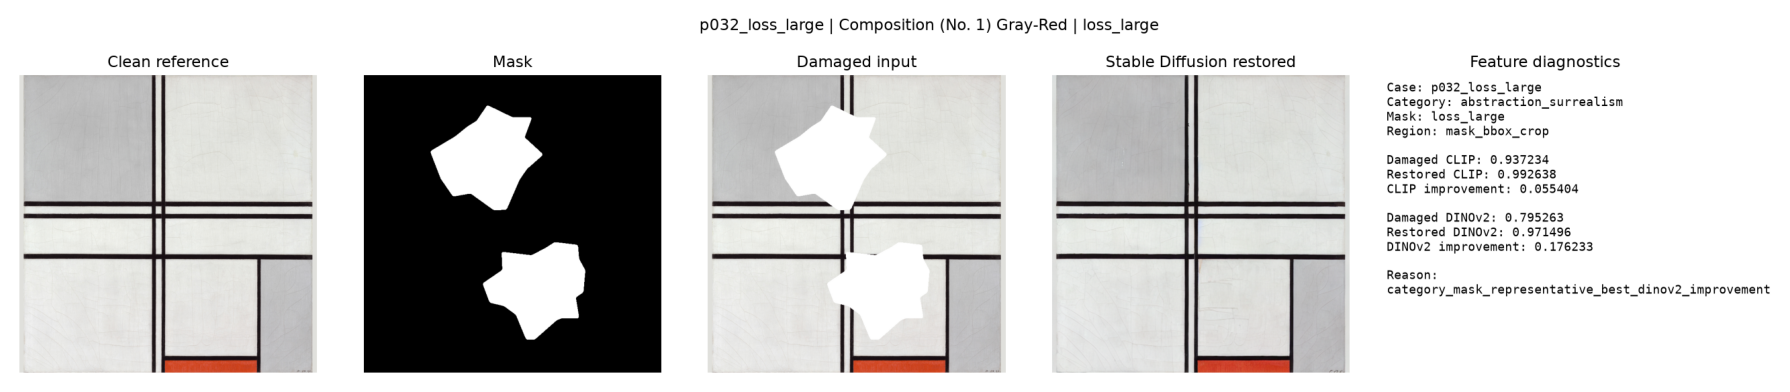

Displaying p050_loss_large | high_texture_brushwork | loss_large | category_mask_representative_best_dinov2_improvement; strongest_mask_bbox_clip_improvement; strongest_mask_bbox_dinov2_improvement


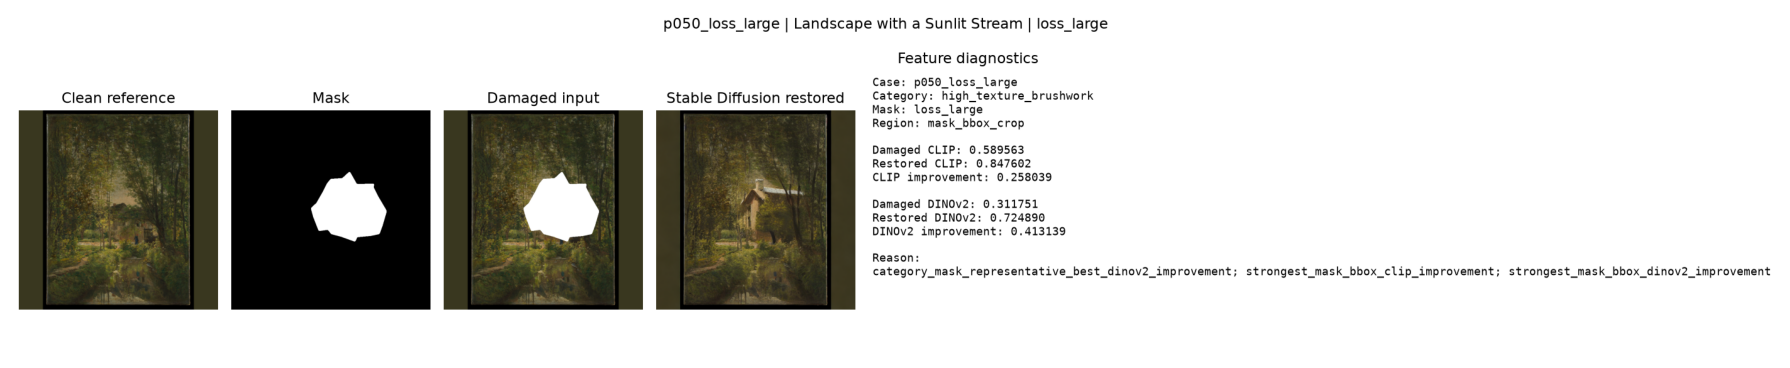

Displaying p048_mixed_damage | high_texture_brushwork | mixed_damage | category_mask_representative_best_dinov2_improvement; strongest_mask_bbox_dinov2_improvement


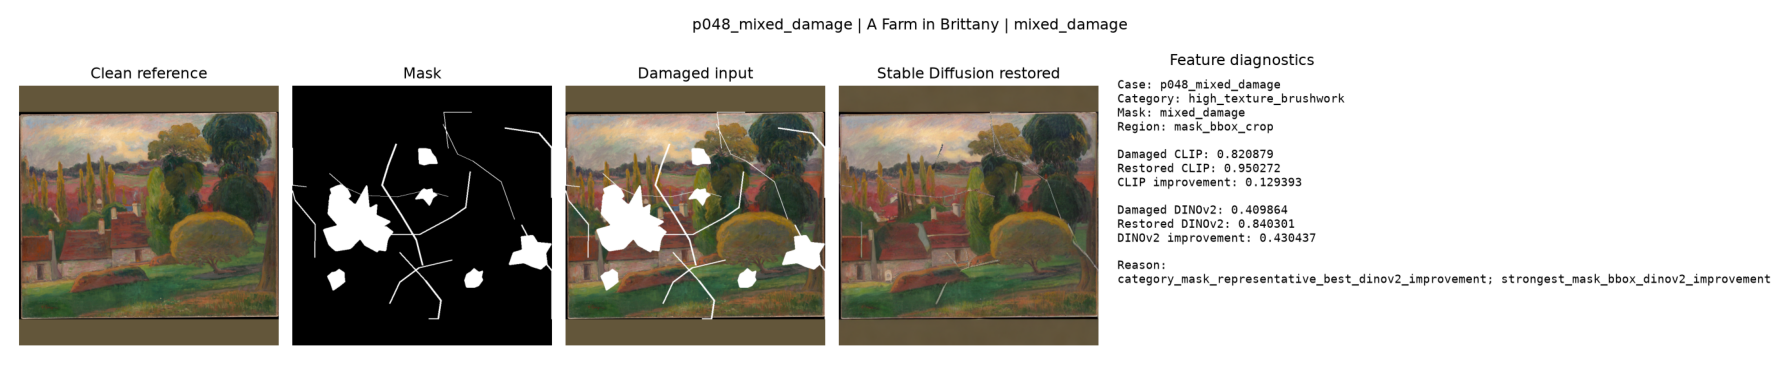

Displaying p028_scratch_thin | architecture_structured | scratch_thin | category_mask_representative_best_dinov2_improvement; weakest_mask_bbox_clip_improvement


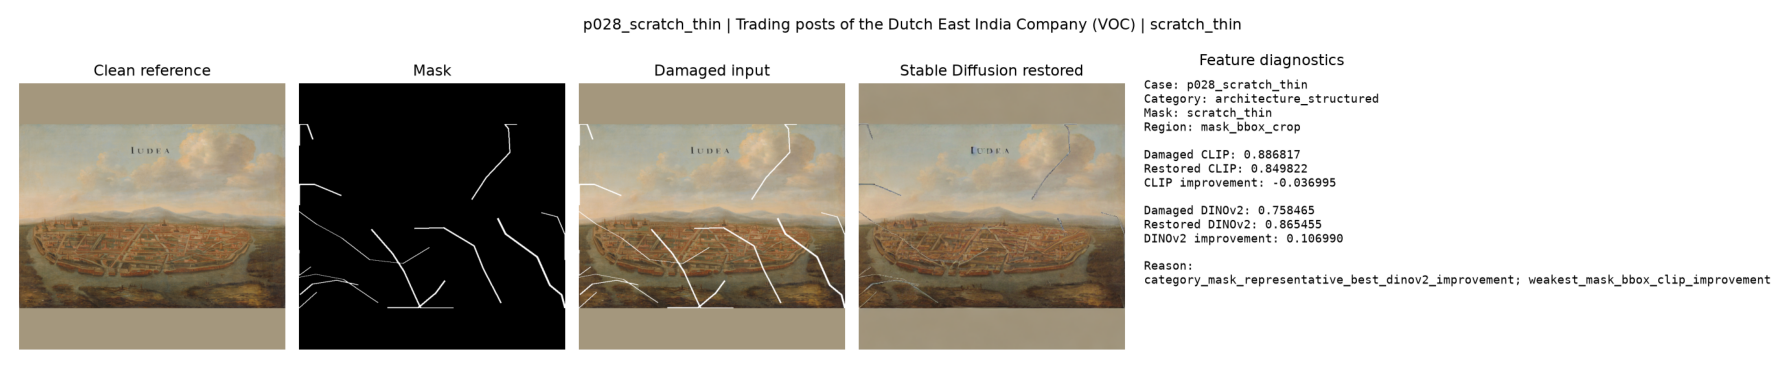

Displaying p040_loss_large | abstraction_surrealism | loss_large | clip_dinov2_metric_disagreement


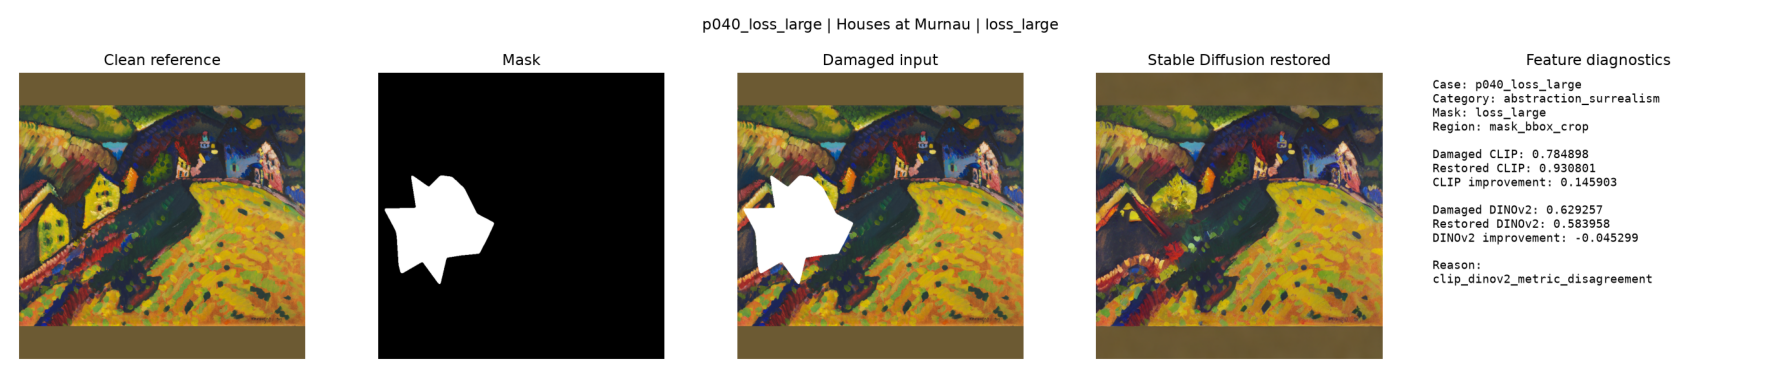

Displaying p025_loss_large | architecture_structured | loss_large | clip_dinov2_metric_disagreement; strongest_mask_bbox_clip_improvement


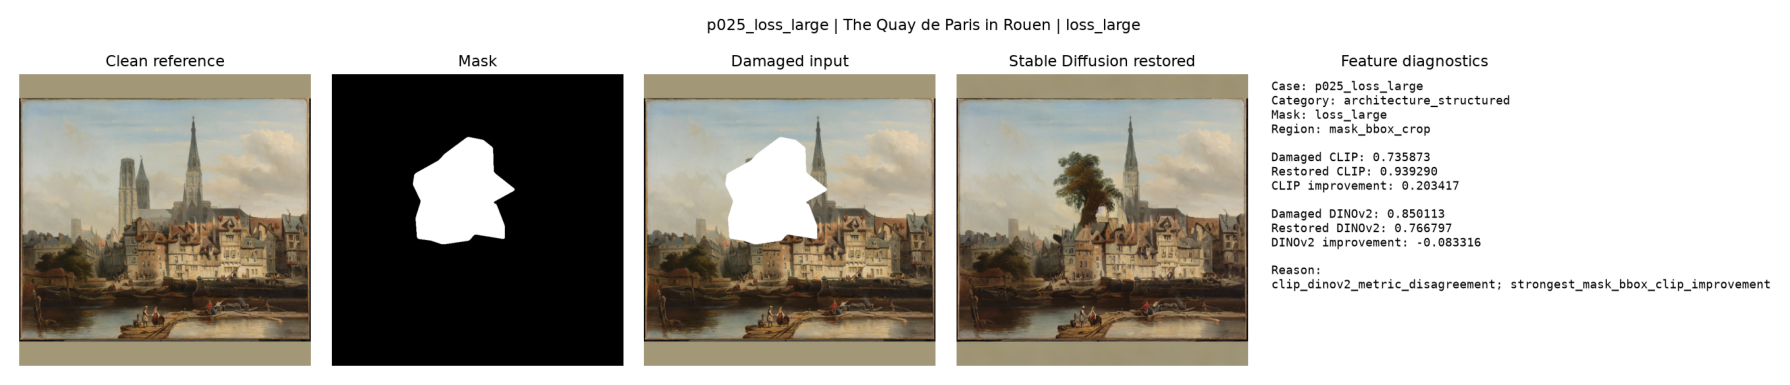

Displaying p011_loss_large | landscape_natural | loss_large | clip_dinov2_metric_disagreement; weakest_mask_bbox_clip_improvement


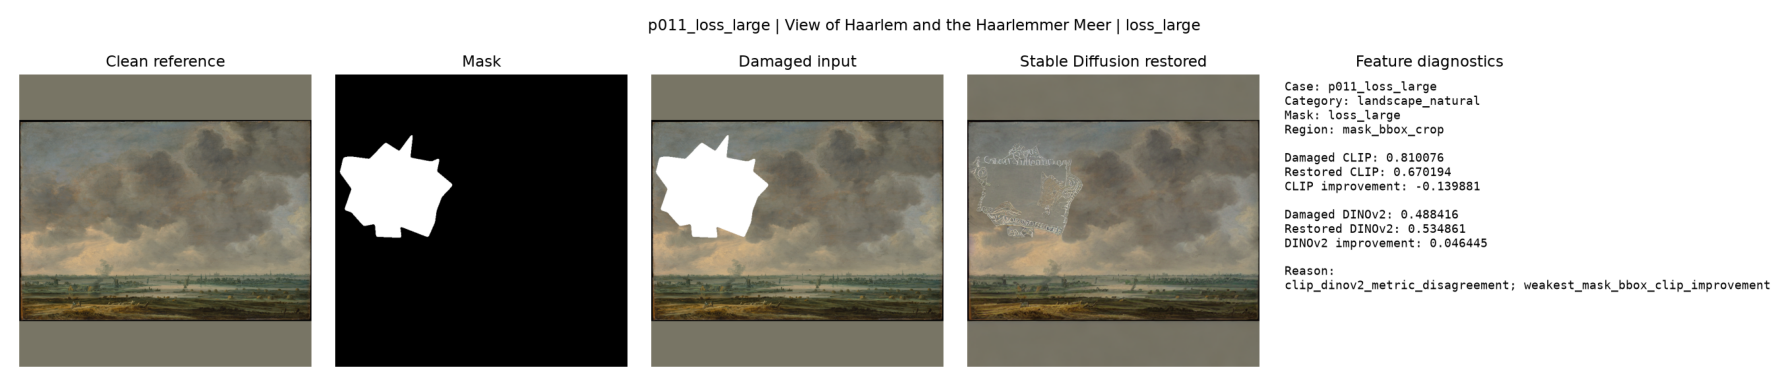

Displaying p028_loss_large | architecture_structured | loss_large | clip_dinov2_metric_disagreement; weakest_mask_bbox_dinov2_improvement


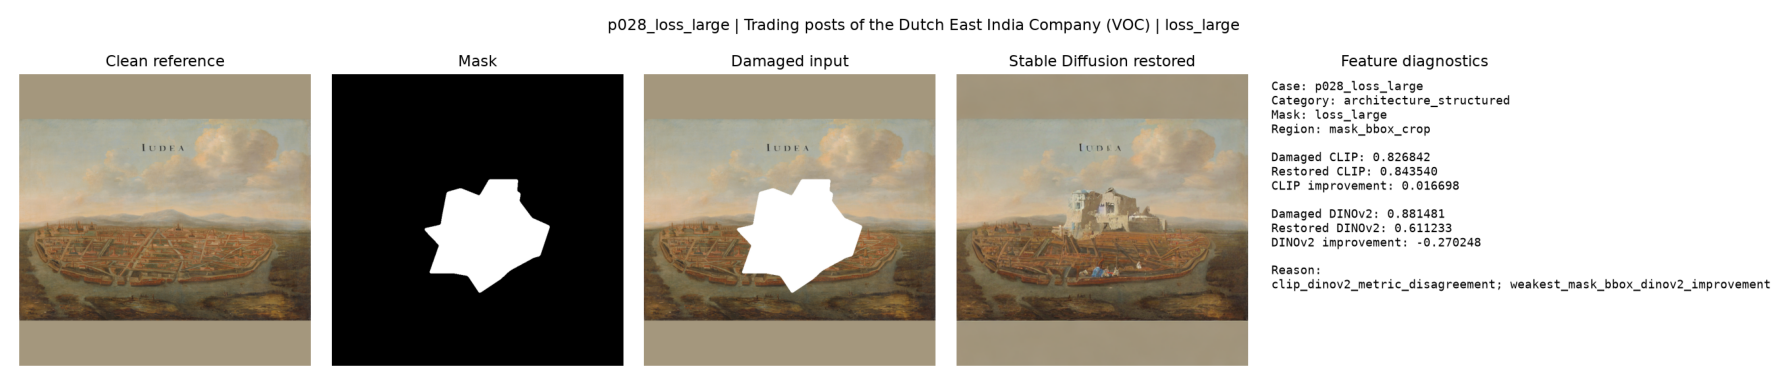

Displaying p025_mixed_damage | architecture_structured | mixed_damage | median_representative_mask_bbox_dinov2_improvement


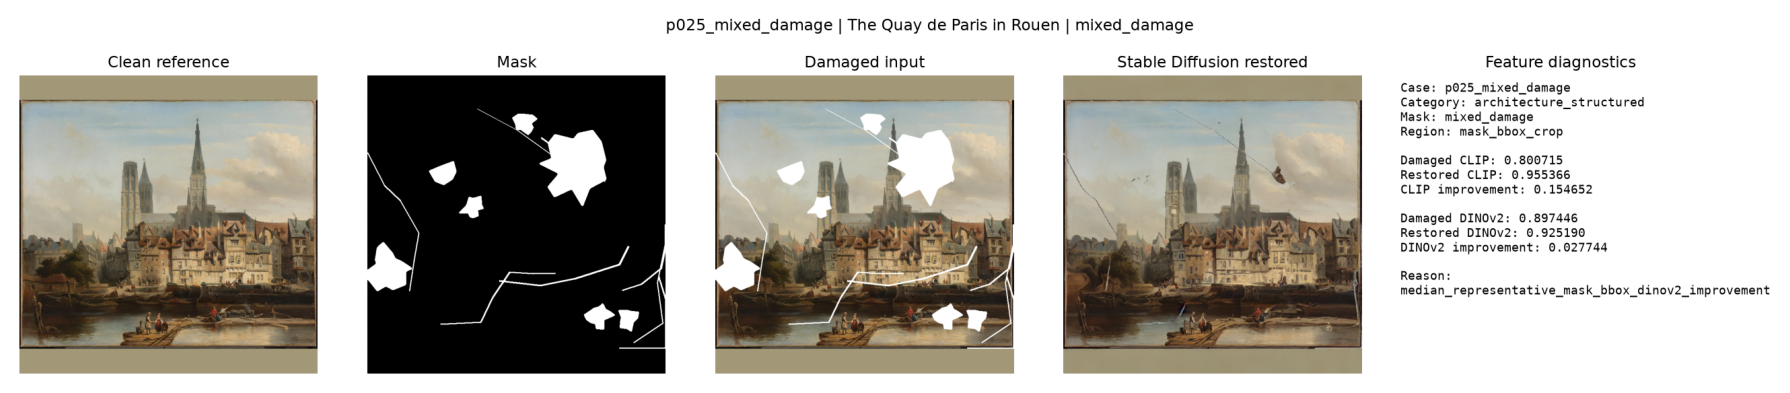

Displaying p048_loss_large | high_texture_brushwork | loss_large | strongest_mask_bbox_clip_improvement


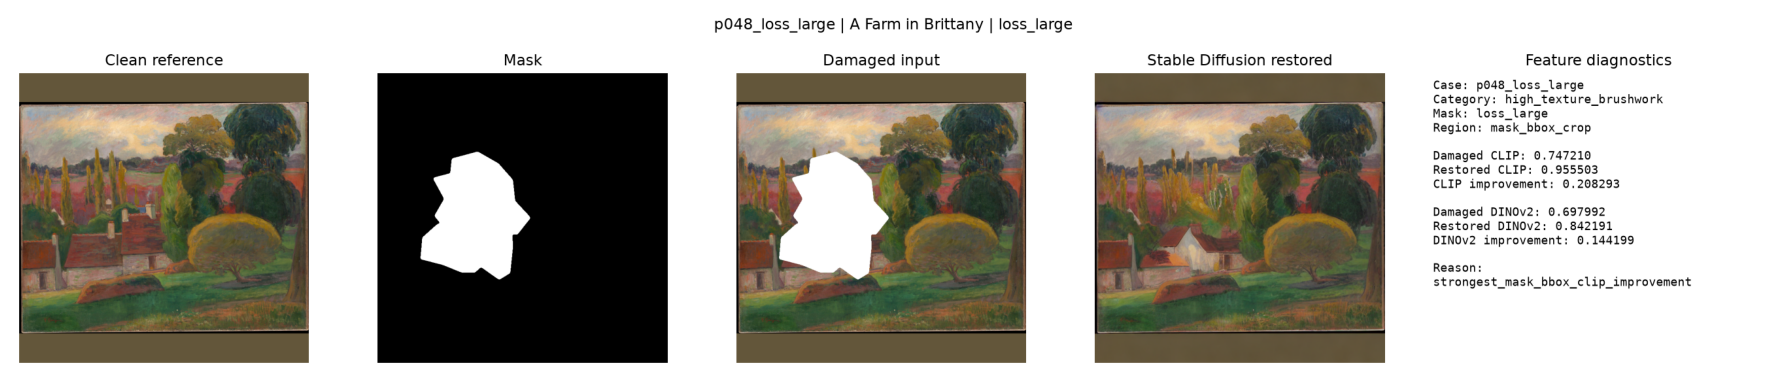

Displaying p044_mixed_damage | high_texture_brushwork | mixed_damage | strongest_mask_bbox_dinov2_improvement


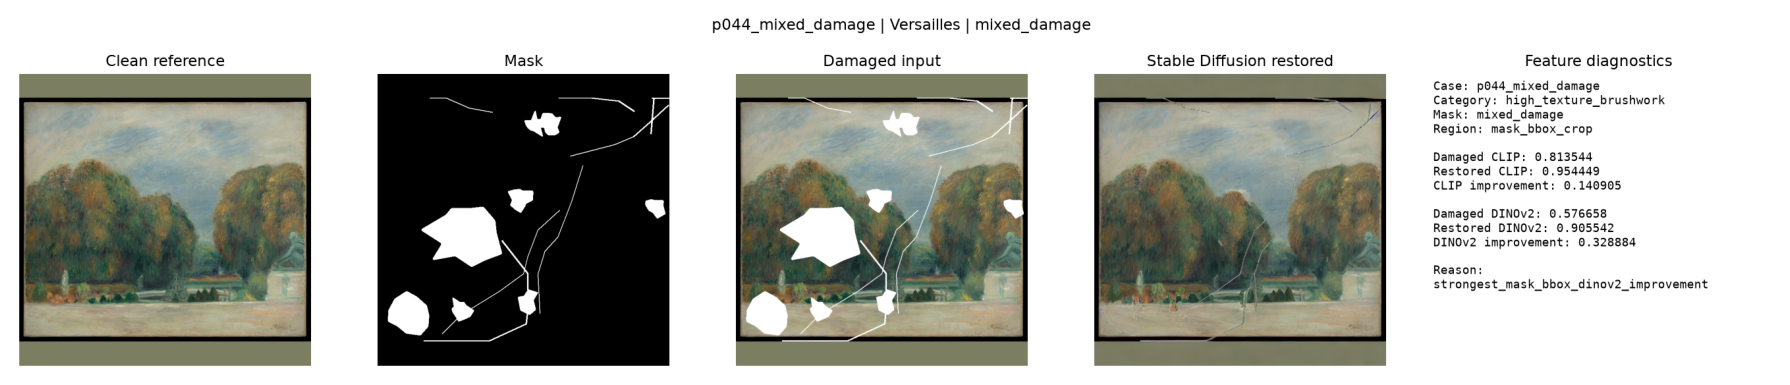

Displaying p038_loss_small | abstraction_surrealism | loss_small | weakest_mask_bbox_clip_improvement


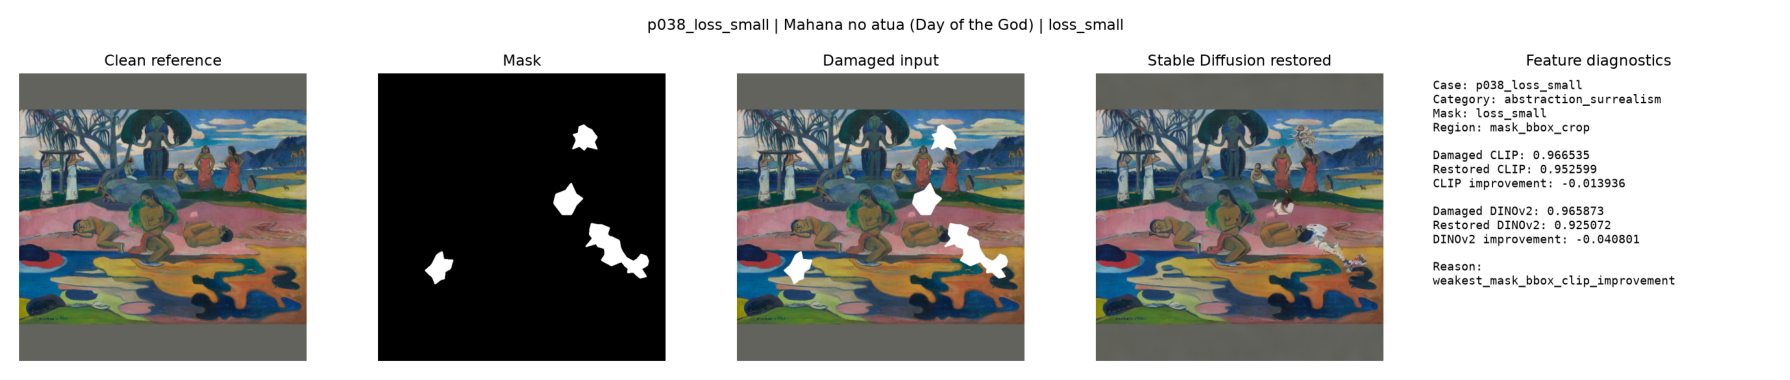

Displaying p012_loss_large | landscape_natural | loss_large | weakest_mask_bbox_clip_improvement; weakest_mask_bbox_dinov2_improvement


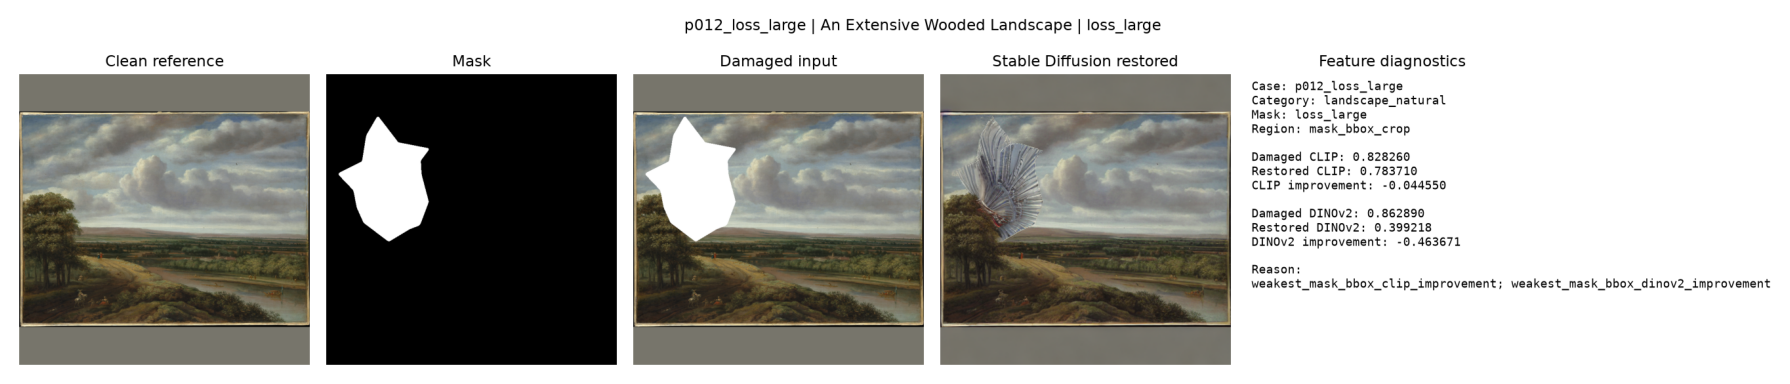

Displaying p042_loss_large | high_texture_brushwork | loss_large | weakest_mask_bbox_dinov2_improvement


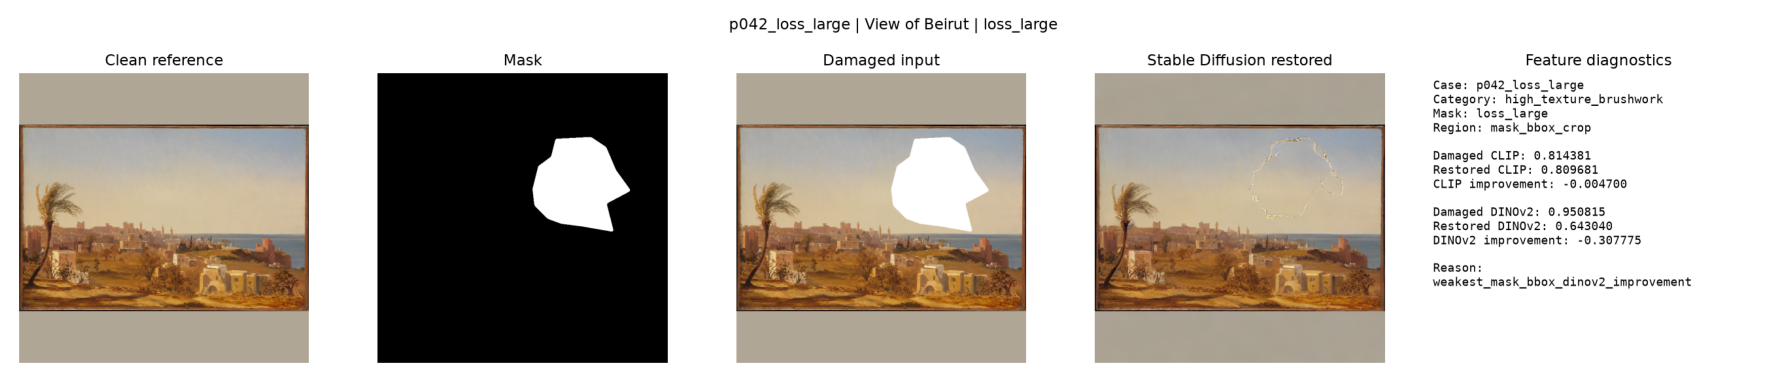

In [22]:
def display_saved_figure(path_value: str | Path) -> None:
    figure_path = Path(path_value)

    if not figure_path.exists():
        raise FileNotFoundError(f"Missing figure: {figure_path}")

    figure_img = Image.open(figure_path).convert("RGB")

    plt.figure(figsize=(18, 5))
    plt.imshow(figure_img)
    plt.axis("off")
    plt.tight_layout()
    plt.show()


sample_visual_df = (
    visual_cases_df
    .sort_values(["selection_reason", "category", "mask_type", "case_id"])
    .groupby("selection_reason", dropna=False)
    .head(1)
    .copy()
)

print("Displaying sample Stable Diffusion feature-similarity visual figures:", len(sample_visual_df))

display(
    sample_visual_df[
        [
            "case_id",
            "category",
            "mask_type",
            "selection_reason",
            "visual_figure_path",
        ]
    ]
)

for _, row in sample_visual_df.iterrows():
    print(
        f"Displaying {row['case_id']} | "
        f"{row['category']} | {row['mask_type']} | "
        f"{row['selection_reason']}"
    )
    display_saved_figure(row["visual_figure_path"])

In [23]:
expected_feature_files = [
    feature_metrics_path,
    summary_by_mask_type_path,
    summary_by_category_path,
    summary_by_region_path,
    summary_by_region_mask_type_path,
    mask_bbox_summary_path,
    strongest_dinov2_cases_path,
    weakest_dinov2_cases_path,
    strongest_clip_cases_path,
    weakest_clip_cases_path,
    visual_cases_manifest_path,
]

for output_file in expected_feature_files:
    if not output_file.exists():
        raise FileNotFoundError(
            f"Missing expected Stable Diffusion feature-similarity output: {output_file}"
        )

saved_feature_df = pd.read_csv(feature_metrics_path)
saved_summary_by_mask_type_df = pd.read_csv(summary_by_mask_type_path)
saved_summary_by_category_df = pd.read_csv(summary_by_category_path)
saved_summary_by_region_df = pd.read_csv(summary_by_region_path)
saved_summary_by_region_mask_type_df = pd.read_csv(summary_by_region_mask_type_path)
saved_mask_bbox_summary_df = pd.read_csv(mask_bbox_summary_path)
saved_strongest_dinov2_df = pd.read_csv(strongest_dinov2_cases_path)
saved_weakest_dinov2_df = pd.read_csv(weakest_dinov2_cases_path)
saved_strongest_clip_df = pd.read_csv(strongest_clip_cases_path)
saved_weakest_clip_df = pd.read_csv(weakest_clip_cases_path)
saved_visual_cases_df = pd.read_csv(visual_cases_manifest_path)

if len(saved_feature_df) != 700:
    raise ValueError(
        f"Expected 700 saved feature-similarity rows, found {len(saved_feature_df)}."
    )

if (saved_feature_df["status"] != "ok").any():
    display(saved_feature_df[saved_feature_df["status"] != "ok"])
    raise ValueError("Saved Stable Diffusion feature-similarity metrics contain non-ok rows.")

expected_region_counts = {
    "full_image": 250,
    "content_region": 250,
    "mask_bbox_crop": 200,
}

actual_region_counts = saved_feature_df["evaluation_region"].value_counts().to_dict()

print("Expected region counts:", expected_region_counts)
print("Actual region counts:", actual_region_counts)

for region, expected_count in expected_region_counts.items():
    actual_count = actual_region_counts.get(region, 0)

    if actual_count != expected_count:
        raise ValueError(
            f"Saved feature region {region!r}: expected {expected_count}, found {actual_count}."
        )

unexpected_regions = set(actual_region_counts) - set(expected_region_counts)

if unexpected_regions:
    raise ValueError(f"Unexpected saved feature regions: {unexpected_regions}")

expected_flat_mask_counts = {
    "loss_large": 150,
    "loss_small": 150,
    "mixed_damage": 150,
    "scratch_thin": 150,
    "zero_control": 100,
}

actual_flat_mask_counts = saved_feature_df["mask_type"].value_counts().to_dict()

print("\nExpected flat mask counts:", expected_flat_mask_counts)
print("Actual flat mask counts:", actual_flat_mask_counts)

for mask_type, expected_count in expected_flat_mask_counts.items():
    actual_count = actual_flat_mask_counts.get(mask_type, 0)

    if actual_count != expected_count:
        raise ValueError(
            f"Saved feature mask type {mask_type!r}: "
            f"expected {expected_count}, found {actual_count}."
        )

expected_category_counts = {
    "portrait_figure": 140,
    "landscape_natural": 140,
    "architecture_structured": 140,
    "abstraction_surrealism": 140,
    "high_texture_brushwork": 140,
}

actual_category_counts = saved_feature_df["category"].value_counts().to_dict()

print("\nExpected category counts:", expected_category_counts)
print("Actual category counts:", actual_category_counts)

for category, expected_count in expected_category_counts.items():
    actual_count = actual_category_counts.get(category, 0)

    if actual_count != expected_count:
        raise ValueError(
            f"Saved feature category {category!r}: expected {expected_count}, found {actual_count}."
        )

if len(saved_summary_by_mask_type_df) != 5:
    raise ValueError(
        f"Expected 5 feature mask-type summary rows, found {len(saved_summary_by_mask_type_df)}."
    )

if len(saved_summary_by_category_df) != 5:
    raise ValueError(
        f"Expected 5 feature category summary rows, found {len(saved_summary_by_category_df)}."
    )

if len(saved_summary_by_region_df) != 3:
    raise ValueError(
        f"Expected 3 feature region summary rows, found {len(saved_summary_by_region_df)}."
    )

if len(saved_mask_bbox_summary_df) != 4:
    raise ValueError(
        f"Expected 4 mask-bounding-box feature summary rows, "
        f"found {len(saved_mask_bbox_summary_df)}."
    )

ranking_outputs = {
    "strongest_dinov2": saved_strongest_dinov2_df,
    "weakest_dinov2": saved_weakest_dinov2_df,
    "strongest_clip": saved_strongest_clip_df,
    "weakest_clip": saved_weakest_clip_df,
}

for ranking_name, ranking_df in ranking_outputs.items():
    if len(ranking_df) != 20:
        raise ValueError(
            f"Expected 20 {ranking_name} rows, found {len(ranking_df)}."
        )

    if set(ranking_df["evaluation_region"].unique()) != {"mask_bbox_crop"}:
        raise ValueError(
            f"{ranking_name} should only contain mask_bbox_crop rows."
        )

for column in feature_metric_columns:
    if column not in saved_feature_df.columns:
        raise ValueError(
            f"Saved feature metrics missing detected feature column: {column}"
        )

if len(saved_visual_cases_df) == 0:
    raise ValueError("Saved Stable Diffusion feature visual cases manifest is empty.")

required_visual_columns = [
    "case_id",
    "painting_id",
    "category",
    "title",
    "mask_type",
    "evaluation_region",
    "selection_reason",
    "visual_figure_path",
]

missing_visual_columns = [
    column for column in required_visual_columns
    if column not in saved_visual_cases_df.columns
]

if missing_visual_columns:
    raise ValueError(
        f"Saved feature visual manifest missing columns: {missing_visual_columns}"
    )

for column in feature_metric_columns:
    if column not in saved_visual_cases_df.columns:
        raise ValueError(
            f"Saved feature visual manifest missing detected feature column: {column}"
        )

missing_visual_figures = [
    path
    for path in saved_visual_cases_df["visual_figure_path"]
    if str(path).strip() == "" or not Path(path).exists()
]

if missing_visual_figures:
    raise FileNotFoundError(
        f"Saved feature visual manifest references missing figures: "
        f"{missing_visual_figures[:10]}"
    )

expected_selection_reasons = [
    "strongest_mask_bbox_dinov2_improvement",
    "weakest_mask_bbox_dinov2_improvement",
    "strongest_mask_bbox_clip_improvement",
    "weakest_mask_bbox_clip_improvement",
    "median_representative_mask_bbox_dinov2_improvement",
    "category_mask_representative_best_dinov2_improvement",
]

selection_reason_text = " ".join(
    saved_visual_cases_df["selection_reason"].fillna("").astype(str).tolist()
)

missing_selection_reasons = [
    reason
    for reason in expected_selection_reasons
    if reason not in selection_reason_text
]

if missing_selection_reasons:
    raise ValueError(
        f"Missing expected feature visual selection reasons: {missing_selection_reasons}"
    )

print("\nSaved Stable Diffusion feature-similarity rows:", len(saved_feature_df))
print("Saved Stable Diffusion feature visual case rows:", len(saved_visual_cases_df))
print("Final Stable Diffusion feature-similarity output gates passed.")

Expected region counts: {'full_image': 250, 'content_region': 250, 'mask_bbox_crop': 200}
Actual region counts: {'full_image': 250, 'content_region': 250, 'mask_bbox_crop': 200}

Expected flat mask counts: {'loss_large': 150, 'loss_small': 150, 'mixed_damage': 150, 'scratch_thin': 150, 'zero_control': 100}
Actual flat mask counts: {'loss_large': 150, 'loss_small': 150, 'mixed_damage': 150, 'scratch_thin': 150, 'zero_control': 100}

Expected category counts: {'portrait_figure': 140, 'landscape_natural': 140, 'architecture_structured': 140, 'abstraction_surrealism': 140, 'high_texture_brushwork': 140}
Actual category counts: {'portrait_figure': 140, 'landscape_natural': 140, 'architecture_structured': 140, 'abstraction_surrealism': 140, 'high_texture_brushwork': 140}

Saved Stable Diffusion feature-similarity rows: 700
Saved Stable Diffusion feature visual case rows: 44
Final Stable Diffusion feature-similarity output gates passed.


## Notebook 22 summary

This notebook computed CLIP and DINOv2 feature-similarity metrics for the Stable Diffusion Inpainting baseline.

Feature similarities were computed between:

- clean reference and damaged input,
- clean reference and Stable Diffusion restored output.

Higher cosine similarity means higher feature-space similarity to the clean reference. Positive improvement means the restored output is closer to the clean reference in feature space than the damaged input.

Evaluated regions:

- `full_image`,
- `content_region`,
- `mask_bbox_crop`.

Sparse `masked_region` pixels are not used because CLIP and DINOv2 expect image-like spatial inputs rather than unordered masked pixels. The `mask_bbox_crop` region is therefore used as the local damage-region proxy.

The final feature-similarity output contains 700 rows:

- 250 full-image rows,
- 250 content-region rows,
- 200 mask-bounding-box crop rows.

Main outputs:

- `outputs/metrics/feature_similarity_stable_diffusion_50.csv`
- `outputs/metrics/feature_similarity_summary_by_mask_type_stable_diffusion_50.csv`
- `outputs/metrics/feature_similarity_summary_by_category_stable_diffusion_50.csv`
- `outputs/metrics/feature_similarity_summary_by_region_stable_diffusion_50.csv`
- `outputs/metrics/feature_similarity_summary_by_region_mask_type_stable_diffusion_50.csv`
- `outputs/metrics/feature_similarity_mask_bbox_summary_stable_diffusion_50.csv`
- `outputs/metrics/stable_diffusion_strongest_dinov2_mask_bbox_cases_50.csv`
- `outputs/metrics/stable_diffusion_weakest_dinov2_mask_bbox_cases_50.csv`
- `outputs/metrics/stable_diffusion_strongest_clip_mask_bbox_cases_50.csv`
- `outputs/metrics/stable_diffusion_weakest_clip_mask_bbox_cases_50.csv`
- `outputs/metrics/stable_diffusion_feature_similarity_visual_cases_manifest_50.csv`
- `outputs/figures/stable_diffusion_feature_similarity_cases/`

The strongest and weakest local feature-similarity cases were ranked using `mask_bbox_crop` CLIP and DINOv2 improvement.

This stage completes the Stable Diffusion feature-space metric layer and prepares the model for a Stable Diffusion baseline report.